# Visualisation Results

This notebook will analyse the results coming from the GARG-AML scores, AutoAudit and Flowscope. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- canonical model names (added by patch_visualisation_results.py) ---
import os, sys
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _REPO_ROOT not in sys.path:
    sys.path.append(_REPO_ROOT)
from src.utils.naming import (
    MODEL_DISPLAY_NAMES,
    MODEL_ORDER,
    pretty,
    pretty_many,
    gargaml_key,
)


In [2]:
models = [
    'flowscope', 
    'autoaudit', 
    'gargaml_u',
    'gargaml_d', 
    'gargaml_tree_u',
    'gargaml_boost_u', 
    'gargaml_tree_d',
    'gargaml_boost_d'
]

patterns = [
    'laundering', 
    'separate',
    'new_mules', 
    'existing_mules'
]

In [3]:
datasets = []

n_nodes_list = [100, 10000, 100000] # Number of nodes in the graph
m_edges_list = [1, 2, 5] # Number of edges to attach from a new node to existing nodes
p_edges_list = [0.001, 0.01] # Probability of adding an edge between two nodes
generation_method_list = [
    'Barabasi-Albert', 
    'Erdos-Renyi', 
    'Watts-Strogatz'
    ] # Generation method for the graph
n_patterns_list = [3, 5] # Number of smurfing patterns to add

for n_nodes in n_nodes_list:
        for n_patterns in n_patterns_list:
            if n_patterns <= 0.06*n_nodes:
                for generation_method in generation_method_list:
                    if generation_method == 'Barabasi-Albert':
                        p_edges = 0
                        for m_edges in m_edges_list:
                            string_name = 'synthetic_' + generation_method + '_'  + str(n_nodes) + '_' + str(m_edges) + '_' + str(p_edges) + '_' + str(n_patterns)
                            datasets.append(string_name)
                    if generation_method == 'Erdos-Renyi':
                        m_edges = 0
                        for p_edges in p_edges_list:
                            string_name = 'synthetic_' + generation_method + '_'  + str(n_nodes) + '_' + str(m_edges) + '_' + str(p_edges) + '_' + str(n_patterns)
                            datasets.append(string_name)
                    if generation_method == 'Watts-Strogatz':
                        for m_edges in m_edges_list:
                            for p_edges in p_edges_list:
                                string_name = 'synthetic_' + generation_method + '_'  + str(n_nodes) + '_' + str(m_edges) + '_' + str(p_edges) + '_' + str(n_patterns)
                                datasets.append(string_name)

In [4]:
file = '../results-aa/synthetic_autoaudit_combined_2.csv'
df = pd.read_csv(file)
df = df.rename(columns={'Unnamed: 0': 'pattern'})
df.head()

,pattern,synthetic_Barabasi-Albert_100_1_0_3,synthetic_Barabasi-Albert_100_2_0_3,synthetic_Barabasi-Albert_100_5_0_3,synthetic_Erdos-Renyi_100_0_0.001_3,synthetic_Erdos-Renyi_100_0_0.01_3,synthetic_Watts-Strogatz_100_1_0.001_3,synthetic_Watts-Strogatz_100_1_0.01_3,synthetic_Watts-Strogatz_100_2_0.001_3,synthetic_Watts-Strogatz_100_2_0.01_3,...,synthetic_Barabasi-Albert_100000_2_0_5,synthetic_Barabasi-Albert_100000_5_0_5,synthetic_Erdos-Renyi_100000_0_0.001_5,synthetic_Erdos-Renyi_100000_0_0.01_5,synthetic_Watts-Strogatz_100000_1_0.001_5,synthetic_Watts-Strogatz_100000_1_0.01_5,synthetic_Watts-Strogatz_100000_2_0.001_5,synthetic_Watts-Strogatz_100000_2_0.01_5,synthetic_Watts-Strogatz_100000_5_0.001_5,synthetic_Watts-Strogatz_100000_5_0.01_5
0,laundering,"(np.float64(0.5068493150684932), np.float64(0....","(np.float64(0.7777777777777778), np.float64(0....","(np.float64(0.6572769953051644), np.float64(0....","(np.float64(0.55), np.float64(0.36974789915966...","(np.float64(0.5333333333333333), np.float64(0....","(np.float64(0.5370370370370371), np.float64(0....","(np.float64(0.5799086757990868), np.float64(0....","(np.float64(0.4090909090909091), np.float64(0....","(np.float64(0.6210045662100456), np.float64(0....",...,"(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)"
1,separate,"(np.float64(0.18721461187214614), np.float64(0...","(np.float64(0.4102564102564103), np.float64(0....","(np.float64(0.3380281690140845), np.float64(0....","(np.float64(0.20000000000000004), np.float64(0...","(np.float64(0.1466666666666667), np.float64(0....","(np.float64(0.3101851851851852), np.float64(0....","(np.float64(0.17808219178082188), np.float64(0...","(np.float64(0.21717171717171715), np.float64(0...","(np.float64(0.4109589041095891), np.float64(0....",...,"(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)"
2,new_mules,"(np.float64(0.2009132420091324), np.float64(0....","(np.float64(0.09401709401709402), np.float64(0...","(np.float64(0.07511737089201878), np.float64(0...","(np.float64(0.21666666666666667), np.float64(0...","(np.float64(0.20666666666666667), np.float64(0...","(np.float64(0.12037037037037036), np.float64(0...","(np.float64(0.2009132420091324), np.float64(0....","(np.float64(0.0909090909090909), np.float64(0....","(np.float64(0.0867579908675799), np.float64(0....",...,"(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)"
3,existing_mules,"(np.float64(0.1187214611872146), np.float64(0....","(np.float64(0.2735042735042735), np.float64(0....","(np.float64(0.24413145539906103), np.float64(0...","(np.float64(0.13333333333333333), np.float64(0...","(np.float64(0.18000000000000002), np.float64(0...","(np.float64(0.10648148148148147), np.float64(0...","(np.float64(0.2009132420091324), np.float64(0....","(np.float64(0.10101010101010101), np.float64(0...","(np.float64(0.1232876712328767), np.float64(0....",...,"(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)","(0, 0, 0, 0)"


In [5]:
file = '../results-0/synthetic_tree_False_3.csv'
df = pd.read_csv(file)
df = df.rename(columns={'Unnamed: 0': 'pattern'})
df.head()

,pattern,synthetic_Barabasi-Albert_100_1_0_3,synthetic_Barabasi-Albert_100_2_0_3,synthetic_Barabasi-Albert_100_5_0_3,synthetic_Erdos-Renyi_100_0_0.001_3,synthetic_Erdos-Renyi_100_0_0.01_3,synthetic_Watts-Strogatz_100_1_0.001_3,synthetic_Watts-Strogatz_100_1_0.01_3,synthetic_Watts-Strogatz_100_2_0.001_3,synthetic_Watts-Strogatz_100_2_0.01_3,...,synthetic_Barabasi-Albert_100000_2_0_3,synthetic_Barabasi-Albert_100000_5_0_3,synthetic_Erdos-Renyi_100000_0_0.001_3,synthetic_Erdos-Renyi_100000_0_0.01_3,synthetic_Watts-Strogatz_100000_1_0.001_3,synthetic_Watts-Strogatz_100000_1_0.01_3,synthetic_Watts-Strogatz_100000_2_0.001_3,synthetic_Watts-Strogatz_100000_2_0.01_3,synthetic_Watts-Strogatz_100000_5_0.001_3,synthetic_Watts-Strogatz_100000_5_0.01_3
0,laundering,"{'tree': {'AUC_ROC': 0.815734989648033, 'AUC_P...","{'tree': {'AUC_ROC': 0.7697368421052632, 'AUC_...","{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.7558139...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.9821428571428572, 'AUC_...","{'tree': {'AUC_ROC': 0.7919254658385094, 'AUC_...","{'tree': {'AUC_ROC': 0.798136645962733, 'AUC_P...","{'tree': {'AUC_ROC': 0.78125, 'AUC_PR': 0.7375...","{'tree': {'AUC_ROC': 0.8043478260869565, 'AUC_...",...,"{'tree': {'AUC_ROC': 0.75, 'AUC_PR': 0.5003332...","{'tree': {'AUC_ROC': 0.7727272727272727, 'AUC_...","{'tree': {'AUC_ROC': 0.6666666666666666, 'AUC_...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.9998499549864959, 'AUC_...","{'tree': {'AUC_ROC': 0.825, 'AUC_PR': 0.650233...","{'tree': {'AUC_ROC': 0.8478260869565217, 'AUC_...","{'tree': {'AUC_ROC': 0.760836220769242, 'AUC_P...","{'tree': {'AUC_ROC': 0.8478260869565217, 'AUC_...","{'tree': {'AUC_ROC': 0.8043478260869565, 'AUC_..."
1,separate,"{'tree': {'AUC_ROC': 0.8201754385964912, 'AUC_...","{'tree': {'AUC_ROC': 0.745945945945946, 'AUC_P...","{'tree': {'AUC_ROC': 0.8015873015873016, 'AUC_...","{'tree': {'AUC_ROC': 0.868421052631579, 'AUC_P...","{'tree': {'AUC_ROC': 0.7467105263157895, 'AUC_...","{'tree': {'AUC_ROC': 0.8888888888888888, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.13636363...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.8333333333333333, 'AUC_...",...,"{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 0.8571428571428572, 'AUC_...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo...","{'tree': {'AUC_ROC': 1.0, 'AUC_PR': 1.0}, 'boo..."
2,new_mules,"{'tree': {'AUC_ROC': 0.6936507936507936, 'AUC_...","{'tree': {'AUC_ROC': 0.6535087719298246, 'AUC_...","{'tree': {'AUC_ROC': 0.5436507936507936, 'AUC_...","{'tree': {'AUC_ROC': 0.47297297297297297, 'AUC...","{'tree': {'AUC_ROC': 0.5805555555555556, 'AUC_...","{'tree': {'AUC_ROC': 0.7857142857142857, 'AUC_...","{'tree': {'AUC_ROC': 0.7, 'AUC_PR': 0.53636363...","{'tree': {'AUC_ROC': 0.9571428571428571, 'AUC_...","{'tree': {'AUC_ROC': 0.9594594594594594, 'AUC_...",...,"{'tree': {'AUC_ROC': 0.6666000133306672, 'AUC_...","{'tree': {'AUC_ROC': 0.8888722244441482, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.00013328...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.00023322...","{'tree': {'AUC_ROC': 0.7142857142857143, 'AUC_...","{'tree': {'AUC_ROC': 0.8749500099980003, 'AUC_...","{'tree': {'AUC_ROC': 0.8333333333333333, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.00016659...","{'tree': {'AUC_ROC': 0.8571428571428572, 'AUC_...","{'tree': {'AUC_ROC': 0.95, 'AUC_PR': 0.9000333..."
3,existing_mules,"{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.11363636...","{'tree': {'AUC_ROC': 0.6594594594594594, 'AUC_...","{'tree': {'AUC_ROC': 0.5, 'AUC_PR': 0.16279069...","{'tree': {'AUC_ROC': 0.6831501831501832, 'AUC_...","{'tree': {'A

In [6]:
eval(df[df['pattern']=='laundering'][datasets[0]].values[0])

{'tree': {'AUC_ROC': 0.815734989648033, 'AUC_PR': 0.7552403736614263},
 'boosting': {'AUC_ROC': 0.815734989648033, 'AUC_PR': 0.7552403736614263}}

In [7]:
def gargaml_results(directed):
    if directed:
        file = '../results-0/results_performance_directed_supervised.txt'
    else:
        file = '../results-0/results_performance_undirected_supervised.txt'
    with open(file, 'r') as f:
        lines = f.readlines()
        
    results_gargaml_dict = {}
    for line in lines:
        model = line.split(':', maxsplit=1)[0].split()[0]
        results = eval(line.split(':', maxsplit=1)[1])
        results_gargaml_dict[model] = results
    return results_gargaml_dict


In [8]:
results_flowscope = pd.read_csv('../results-0/synthetic_flowscope_combined.csv')
results_autoaudit = pd.read_csv('../results-aa/synthetic_autoaudit_combined_2.csv')
results_gargaml_undir = gargaml_results(False)
results_gargaml_dir = gargaml_results(True)
results_gargaml_tree_undir_3 = pd.read_csv('../synthetic_tree_False_3.csv')
results_gargaml_tree_undir_5 = pd.read_csv('../synthetic_tree_False_5.csv')
results_gargaml_tree_undir = results_gargaml_tree_undir_3.merge(
    results_gargaml_tree_undir_5, 
    on='Unnamed: 0', 
)
results_gargaml_tree_dir_3 = pd.read_csv('../synthetic_tree_True_3.csv')
results_gargaml_tree_dir_5 = pd.read_csv('../synthetic_tree_True_5.csv')
results_gargaml_tree_dir = results_gargaml_tree_dir_3.merge(
    results_gargaml_tree_dir_5, 
    on='Unnamed: 0', 
)

In [9]:
results_gargaml_undir[datasets[0]]['laundering']

[0.5042735042735043,
 0.6378378378378379,
 0.5616883116883117,
 0.5072378358644606]

In [10]:
results_flowscope.head()

,Unnamed: 0,synthetic_Barabasi-Albert_100_1_0_3,synthetic_Barabasi-Albert_100_2_0_3,synthetic_Barabasi-Albert_100_5_0_3,synthetic_Erdos-Renyi_100_0_0.001_3,synthetic_Erdos-Renyi_100_0_0.01_3,synthetic_Watts-Strogatz_100_1_0.001_3,synthetic_Watts-Strogatz_100_1_0.01_3,synthetic_Watts-Strogatz_100_2_0.001_3,synthetic_Watts-Strogatz_100_2_0.01_3,...,synthetic_Barabasi-Albert_100000_2_0_5,synthetic_Barabasi-Albert_100000_5_0_5,synthetic_Erdos-Renyi_100000_0_0.001_5,synthetic_Erdos-Renyi_100000_0_0.01_5,synthetic_Watts-Strogatz_100000_1_0.001_5,synthetic_Watts-Strogatz_100000_1_0.01_5,synthetic_Watts-Strogatz_100000_2_0.001_5,synthetic_Watts-Strogatz_100000_2_0.01_5,synthetic_Watts-Strogatz_100000_5_0.001_5,synthetic_Watts-Strogatz_100000_5_0.01_5
0,laundering,"[0.8947368421052632, 0.6415094339622641, np.fl...","[0.4523809523809524, 0.2814814814814815, np.fl...","[0.5609756097560976, 0.4107142857142857, np.fl...","[1.0, 0.5370370370370371, np.float64(0.7341772...","[1.0, 0.35398230088495575, np.float64(0.645161...","[0.8620689655172413, 0.5050505050505051, np.fl...","[0.8, 0.5045045045045045, np.float64(0.6921052...","[0.34615384615384615, 0.22784810126582278, np....","[0.5, 0.2803738317757009, np.float64(0.4632975...",...,"[0.0, 0.0, np.float64(0.49992496248124063), np...","[0.0, 0.0, np.float64(0.4998349141553608), np....","[0.0, 0.0, np.float64(0.49982489844109584), np...","[0.0, 0.0, np.float64(0.5), np.float64(0.00127...","[0.5357142857142857, 0.35502958579881655, np.f...","[0.4166666666666667, 0.09174311926605505, np.f...","[0.29411764705882354, 0.08064516129032258, np....","[0.3125, 0.08130081300813008, np.float64(0.541...","[0.0, 0.0, np.float64(0.4997899075593261), np....","[0.0, 0.0, np.float64(0.49983492571657245), np..."
1,separate,"[0.5263157894736842, 0.6896551724137931, np.fl...","[0.0, 0.0, np.float64(0.39126016260162605), np...","[0.2926829268292683, 0.36923076923076925, np.f...","[0.8275862068965517, 0.8571428571428571, np.fl...","[1.0, 0.851063829787234, np.float64(1.0), np.f...","[0.6551724137931034, 0.6666666666666666, np.fl...","[0.2, 0.2545454545454545, np.float64(0.7222222...","[0.0, 0.0, np.float64(0.3486238532110092), np....","[0.0, 0.0, np.float64(0.3318965517241379), np....",...,"[0.0, 0.0, np.float64(0.49992502249325205), np...","[0.0, 0.0, np.float64(0.4998350544320374), np....","[0.0, 0.0, np.float64(0.4998250594797769), np....","[0.0, 0.0, np.float64(0.5), np.float64(0.00043...","[0.125, 0.14432989690721648, np.float64(0.7557...","[0.0, 0.0, np.float64(0.49991502039510516), np...","[0.0, 0.0, np.float64(0.4998800359892032), np....","[0.0, 0.0, np.float64(0.4998250419899224), np....","[0.0, 0.0, np.float64(0.49979008186807145), np...","[0.0, 0.0, np.float64(0.4998350395904983), np...."
2,new_mules,"[0.0, 0.0, np.float64(0.22807017543859648), np...","[0.07142857142857142, 0.08450704225352113, np....","[0.024390243902439025, 0.03125, np.float64(0.3...","[0.0, 0.0, np.float64(0.34710743801652894), np...","[0.0, 0.0, np.float64(0.3884297520661157), np....","[0.0, 0.0, np.float64(0.3483606557377049), np....","[0.05714285714285714, 0.05970149253731343, np....","[0.038461538461538464, 0.04878048780487805, np...","[0.06666666666666667, 0.07692307692307693, np....",...,"[0.0, 0.0, np.float64(0.49992502174369435), np...","[0.0, 0.0, np.float64(0.49983503629201576), np...","[0.0, 0.0, np.float64(0.4998250752176564), np....","[0.0, 0.0, np.float64(0.5), np.float64(0.00041...","[0.0, 0.0, np.float64(0.4996501084663754), np....","[0.0, 0.0, np.float64(0.49991502039510516), np...","[0.0, 0.0, np.float64(0.49988002999250186), np...","[0.0, 0.0, np.float64(0.4998250437390652), np....","[0.0, 0.0, np.float64(0.4997900524868783), np....","[0.0, 0.0, np.float64(0.4998350560809325), np...."
3,existing_mules,"[0.3684210526315789, 0.509090909090909, np.flo...","[0.38095238095238093, 0.43243243243243246, np....","[0.24390243902439024, 0.3076923076923077, np.f...","[0.1724137931034483, 0.19607843137254902, np.f...","[0.0, 0.0

In [11]:
results_dict = {
    dataset:{
        model:{
            pattern:{
                'Precision': 0,
                'F1-score': 0,
                'AUC-ROC': 0,
                'AUC-PR': 0,
            }
            for pattern in patterns
        }
        for model in models
    }
    for dataset in datasets
}

In [12]:
results_gargaml_tree_undir[datasets[0]]

0    {'tree': {'Precision': 0.8421052631578947, 'F1...
1    {'tree': {'Precision': 0.8, 'F1': 0.7272727272...
2    {'tree': {'Precision': 0.6666666666666666, 'F1...
3    {'tree': {'Precision': 0.0, 'F1': 0.0, 'AUC_RO...
Name: synthetic_Barabasi-Albert_100_1_0_3, dtype: object

In [13]:
for dataset in datasets:
    for model in models:
        if model =='flowscope':
            for pattern in patterns:
                precision, f1_score, ROC, PR = tuple(eval(results_flowscope[results_flowscope['Unnamed: 0']==pattern][dataset].values[0]))
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'autoaudit':
            for pattern in patterns:
                precision, f1_score, ROC, PR = tuple(eval(results_autoaudit[results_autoaudit['Unnamed: 0']==pattern][dataset].values[0]))
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'gargaml_u':
            for pattern in patterns:
                try:
                    precision, f1_score, ROC, PR = tuple(results_gargaml_undir[dataset][pattern])
                except:
                    precision = f1_score = ROC = PR = 0
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'gargaml_d':
            for pattern in patterns:
                try:
                    precision, f1_score, ROC, PR = tuple(results_gargaml_dir[dataset][pattern])
                except:
                    precision = f1_score = ROC = PR = 0
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
            
        if model == 'gargaml_tree_u':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_undir[results_gargaml_tree_undir['Unnamed: 0']==pattern][dataset].values[0])['tree']
                    precision = dict_values['Precision']
                    f1_score = dict_values['F1']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    precision = f1_score = ROC = PR = 0
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR

        if model == 'gargaml_tree_d':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_dir[results_gargaml_tree_dir['Unnamed: 0']==pattern][dataset].values[0])['tree']
                    precision = dict_values['Precision']
                    f1_score = dict_values['F1']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    precision = f1_score = ROC = PR = 0
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR

        if model == 'gargaml_boost_u':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_undir[results_gargaml_tree_undir['Unnamed: 0']==pattern][dataset].values[0])['boosting']
                    precision = dict_values['Precision']
                    f1_score = dict_values['F1']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    precision = f1_score = ROC = PR = 0
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR
        if model == 'gargaml_boost_d':
            for pattern in patterns:
                try:
                    dict_values = eval(results_gargaml_tree_dir[results_gargaml_tree_dir['Unnamed: 0']==pattern][dataset].values[0])['boosting']
                    precision = dict_values['Precision']
                    f1_score = dict_values['F1']
                    ROC = dict_values['AUC_ROC']
                    PR = dict_values['AUC_PR']
                except:
                    precision = f1_score = ROC = PR = 0
                results_dict[dataset][model][pattern]['Precision'] = precision
                results_dict[dataset][model][pattern]['F1-score'] = f1_score
                results_dict[dataset][model][pattern]['AUC-ROC'] = ROC
                results_dict[dataset][model][pattern]['AUC-PR'] = PR


In [14]:
dict_values = eval(results_gargaml_tree_undir[results_gargaml_tree_undir['Unnamed: 0']==pattern][dataset].values[0])['boosting']

In [15]:
data = []

for dataset, method_data in results_dict.items():
    for method, pattern_data in method_data.items():
        for pattern, metrics in pattern_data.items():
            data.append({
                'dataset': dataset,
                'method': method,
                'pattern': pattern,
                'performance_metric': 'Precision', 
                'performance': metrics['Precision']
            })
            
            data.append({
                'dataset': dataset,
                'method': method,
                'pattern': pattern,
                'performance_metric': 'F1-score', 
                'performance': metrics['F1-score']
            })
            
            data.append({
                'dataset': dataset,
                'method': method,
                'pattern': pattern,
                'performance_metric': 'AUC-ROC', 
                'performance': metrics['AUC-ROC']
            })

            data.append({
                'dataset': dataset,
                'method': method,
                'pattern': pattern,
                'performance_metric': 'AUC-PR', 
                'performance': metrics['AUC-PR']
            })
df = pd.DataFrame(data)
df.head(10)

,dataset,method,pattern,performance_metric,performance
0,synthetic_Barabasi-Albert_100_1_0_3,flowscope,laundering,Precision,0.894737
1,synthetic_Barabasi-Albert_100_1_0_3,flowscope,laundering,F1-score,0.641509
2,synthetic_Barabasi-Albert_100_1_0_3,flowscope,laundering,AUC-ROC,0.660428
3,synthetic_Barabasi-Albert_100_1_0_3,flowscope,laundering,AUC-PR,0.664871
4,synthetic_Barabasi-Albert_100_1_0_3,flowscope,separate,Precision,0.526316
5,synthetic_Barabasi-Albert_100_1_0_3,flowscope,separate,F1-score,0.689655
6,synthetic_Barabasi-Albert_100_1_0_3,flowscope,separate,AUC-ROC,0.923600
7,synthetic_Barabasi-Albert_100_1_0_3,flowscope,separate,AUC-PR,0.511842
8,synthetic_Barabasi-Albert_100_1_0_3,flowscope,new_mules,Precision,0.000000
9,synthetic_Barabasi-Albert_100_1_0_3,flowscope,new_mules,F1-score,0.000000


In [16]:
import seaborn as sns

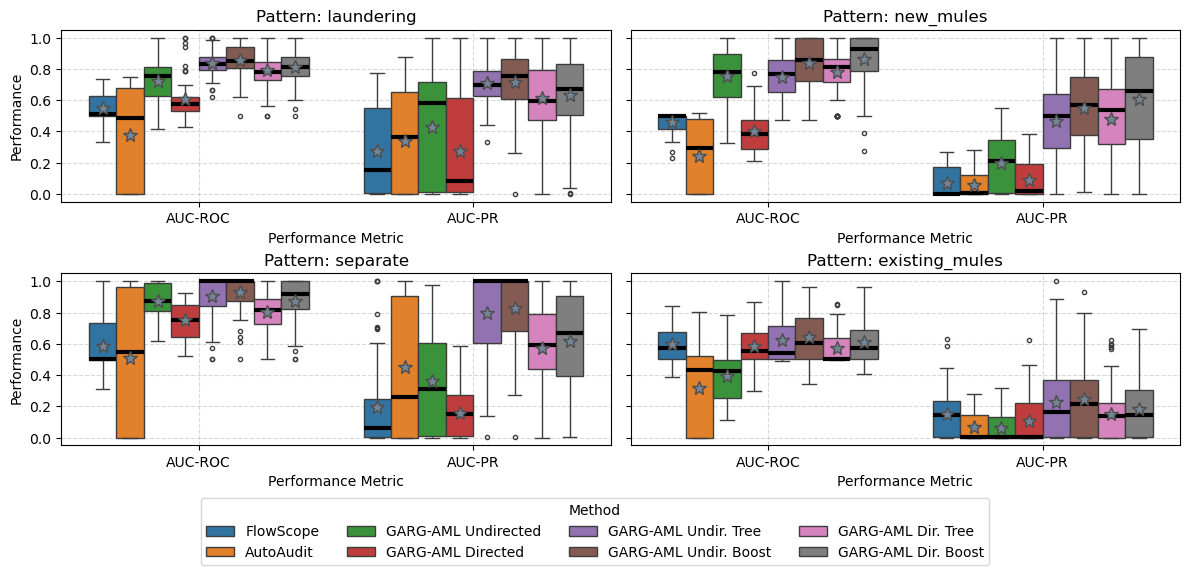

In [23]:
# Restrict to threshold-free metrics and apply canonical model display names.
df_plot = df[df['performance_metric'].isin(['AUC-ROC', 'AUC-PR'])].copy()
df_plot['method'] = df_plot['method'].map(pretty)

fig, axes = plt.subplots(2, 2, figsize=(12, 5.5), sharey=True)

for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        pattern = patterns[i + 2 * j]

        sns.boxplot(
            ax=ax,
            x='performance_metric', y='performance', hue='method',
            data=df_plot[df_plot['pattern'] == pattern],
            palette='tab10', fliersize=3, showmeans=True,
            meanprops={'marker': '*', 'markerfacecolor': 'xkcd:steel',
                       'markeredgecolor': '.3', 'markersize': 10},
            medianprops={'color': 'black', 'linewidth': 3,
                         'label': '_median_'},
        )
        ax.set_title('Pattern: ' + pattern)
        ax.grid(True, which='both', ls='--', c='gray', alpha=0.3)
        # Y-label only on the left column, x-label only on the bottom row.
        ax.set_ylabel('Performance' if j == 0 else '')
        ax.set_xlabel('Performance Metric')

# Capture handles+labels once, then remove the per-axes legends.
handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Single shared legend at the bottom, 4 columns x 2 rows.
fig.legend(
    handles, labels,
    loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05),
    frameon=True, title='Method',
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig('../results/boxplot_performance_full.pdf', bbox_inches='tight')


In [18]:
import pandas as pd

# 1. Define your desired order exactly as you want them to appear
pattern_order = ['laundering', 'separate', 'existing_mules', 'new_mules']
method_order = ['flowscope', 'autoaudit', 'gargaml_u', 'gargaml_d', 
                'gargaml_tree_u', 'gargaml_boost_u', 'gargaml_tree_d', 'gargaml_boost_d']
metric_order = [
    'Precision',
    'F1-score',
    'AUC-ROC', 
    'AUC-PR'
    ]

# 2. Aggregation (as before)
stats = df.groupby(['pattern', 'method', 'performance_metric'])['performance'].agg(['mean', 'std']).reset_index()
stats['display'] = stats.apply(lambda x: f"${x['mean']:.3f} \pm {x['std']:.3f}$", axis=1)

# 3. Pivot the table
latex_table = stats.pivot(index=['pattern', 'method'], columns='performance_metric', values='display')

# 4. CRITICAL STEP: Reorder the index and columns
# We use .reindex to force the specific order defined above
latex_table = latex_table.reindex(index=pattern_order, level=0)   # Order Patterns
latex_table = latex_table.reindex(index=method_order, level=1)    # Order Methods within Patterns
latex_table = latex_table.reindex(columns=metric_order)           # Order Columns (ROC then PR)

# 5. Export with professional formatting
# Note: 'index=True' and 'multirow=True' creates the nested row look
latex_code = latex_table.to_latex(
    escape=False, 
    index=True, 
    multirow=True,
    column_format='llcc', # 'l' for text, 'c' for numbers
    caption='Performance Comparison Across Patterns',
    label='tab:results'
)

print(latex_code)

\begin{table}
\centering
\caption{Performance Comparison Across Patterns}
\label{tab:results}
\begin{tabular}{llcc}
\toprule
          & performance_metric &          Precision &           F1-score &            AUC-ROC &             AUC-PR \\
pattern & method &                    &                    &                    &                    \\
\midrule
\multirow{8}{*}{laundering} & flowscope &  $0.417 \pm 0.348$ &  $0.192 \pm 0.182$ &  $0.547 \pm 0.097$ &  $0.272 \pm 0.290$ \\
          & autoaudit &  $0.219 \pm 0.312$ &  $0.194 \pm 0.268$ &  $0.374 \pm 0.314$ &  $0.336 \pm 0.334$ \\
          & gargaml_u &  $0.539 \pm 0.458$ &  $0.460 \pm 0.365$ &  $0.723 \pm 0.128$ &  $0.426 \pm 0.371$ \\
          & gargaml_d &  $0.340 \pm 0.365$ &  $0.164 \pm 0.176$ &  $0.607 \pm 0.122$ &  $0.274 \pm 0.336$ \\
          & gargaml_tree_u &  $0.929 \pm 0.087$ &  $0.801 \pm 0.090$ &  $0.837 \pm 0.080$ &  $0.707 \pm 0.143$ \\
          & gargaml_boost_u &  $0.886 \pm 0.170$ &  $0.803 \pm 0.148$ &  $0.

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_3804/2080424987.py:29: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_code = latex_table.to_latex(


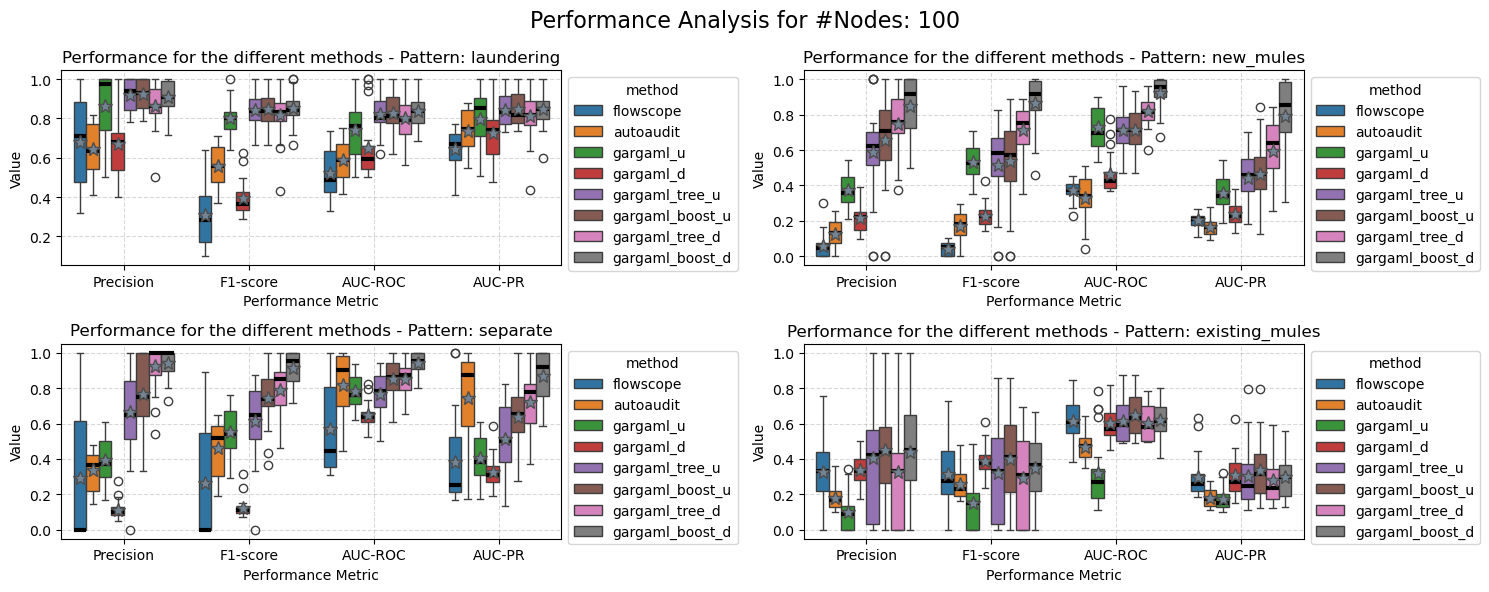

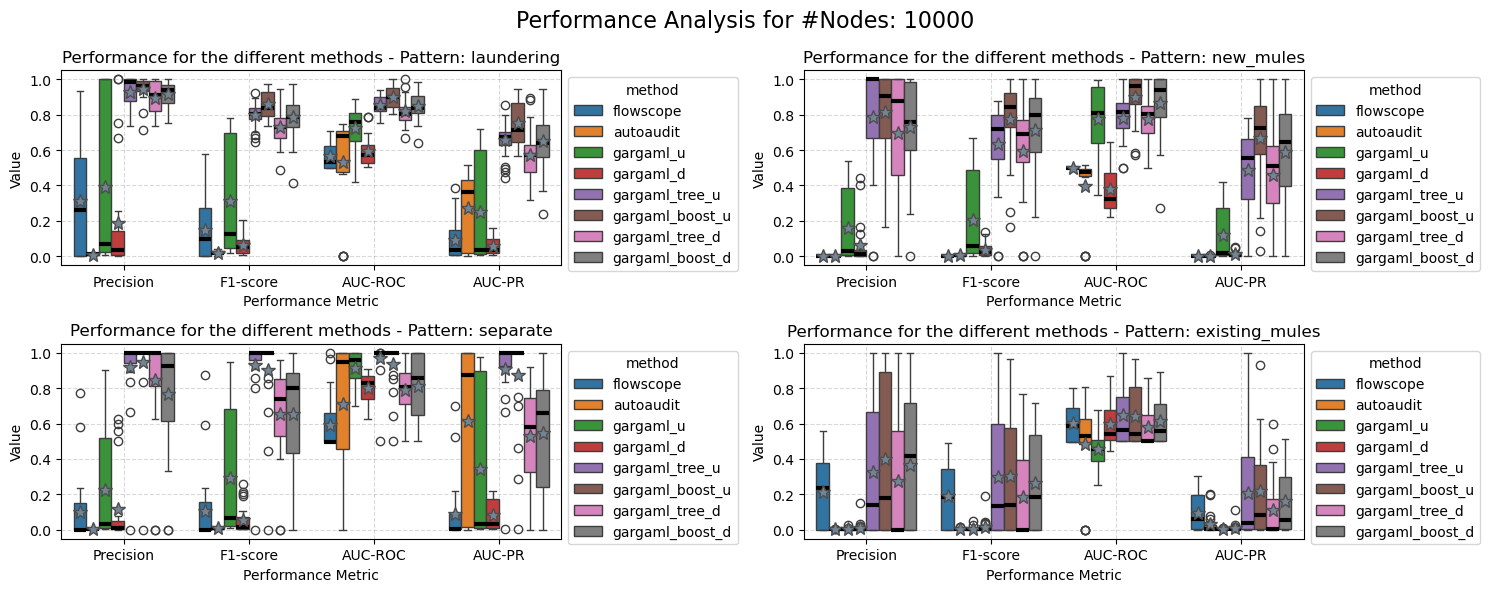

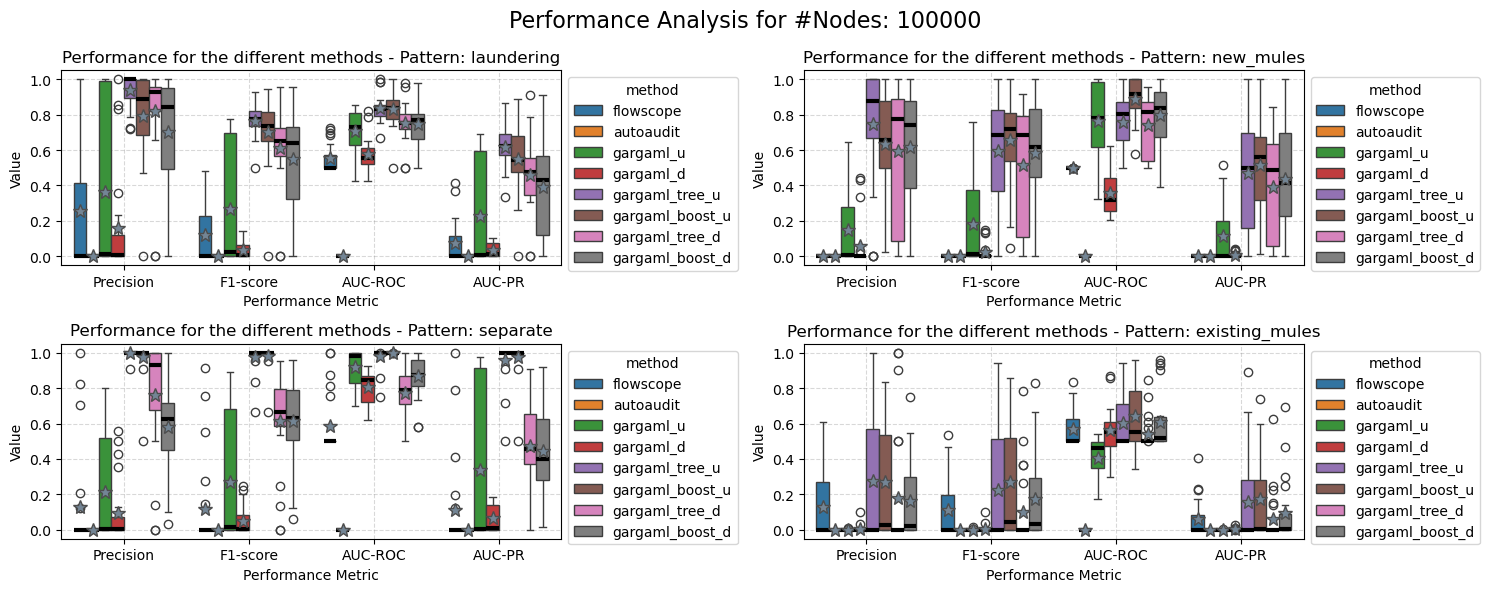

In [19]:
for n_nodes in n_nodes_list:
    fig, axes = plt.subplots(2, 2, figsize=(15, 6))
    for i in range(2):
        for j in range(2): 
            pattern = patterns[i+2*j]

            sns.boxplot(ax=axes[i,j], x='performance_metric', y='performance', hue='method', data=df[(df['pattern']==pattern)&(df['dataset'].str.contains('_'+str(n_nodes)+'_'))], palette='tab10',showmeans=True, meanprops={'marker':'*', 'markerfacecolor':'xkcd:steel', 'markeredgecolor':'.3', 'markersize': 10}, medianprops={'color': 'black', 'linewidth':2,'label': '_median_', 'linewidth':3})
            axes[i,j].set_title('Performance for the different methods - Pattern: '+ pattern)
            axes[i,j].set_xlabel('Performance Metric')
            axes[i,j].set_ylabel('Value')
            axes[i,j].legend(title='method', bbox_to_anchor=(1.0, 1), loc='upper left')
            axes[i,j].grid(True,which="both",ls="--",c='gray', alpha=0.3)

    fig.suptitle(f'Performance Analysis for #Nodes: {n_nodes}', fontsize=16)
    plt.tight_layout()  # Adjust layout to fit the global title

    plt.savefig('../results/boxplot_performance_'+str(n_nodes)+'_full.pdf')

In [20]:
def give_order(models, pattern, dataset):
    # Initialize a dictionary to store the results
    results = {model: {'AUC-ROC': 0, 'AUC-PR': 0} for model in models}

    for model in models:
        results[model]['AUC-ROC'] = results_dict[dataset][model][pattern]['AUC-ROC']
        results[model]['AUC-PR'] = results_dict[dataset][model][pattern]['AUC-PR']

    sorted_models_ROC = []
    sorted_models_PR = []

    sorted_models_ROC_ = sorted(models, key=lambda model: results[model]['AUC-ROC'], reverse=True)
    sorted_models_PR_ = sorted(models, key=lambda model: results[model]['AUC-PR'], reverse=True)
    sorted_models_ROC.append(sorted_models_ROC_)
    sorted_models_PR.append(sorted_models_PR_)

    return sorted_models_ROC, sorted_models_PR

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_3804/3779459503.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_3804/3779459503.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


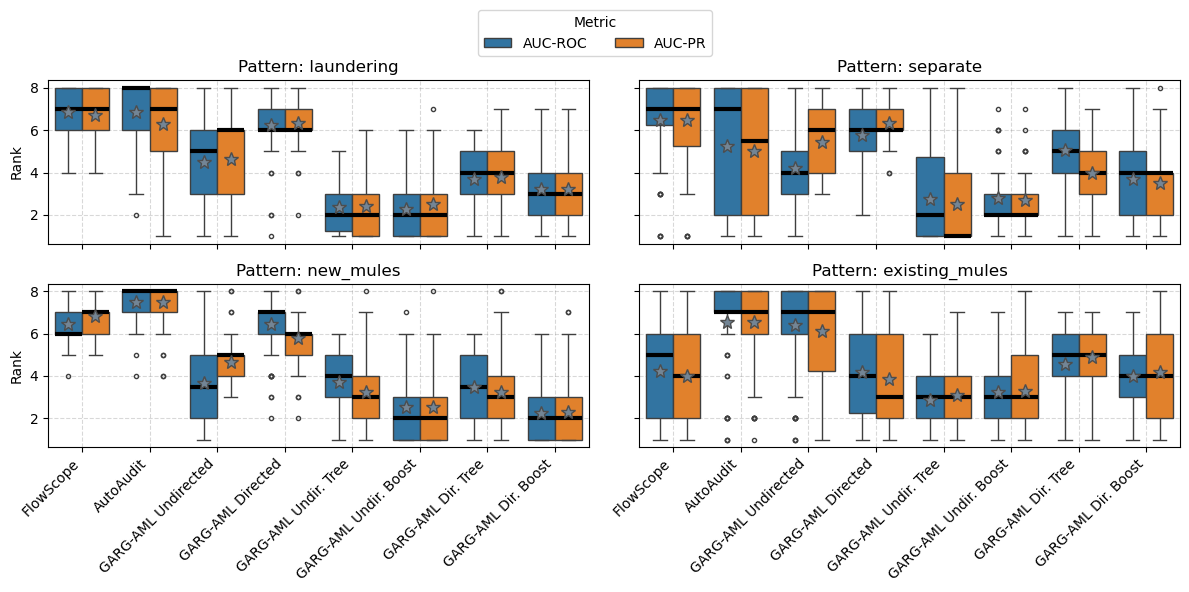

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

for idx, pattern in enumerate(patterns):
    ax = axes[idx // 2, idx % 2]

    sorted_models_ROC_list = []
    sorted_models_PR_list = []

    for dataset in datasets:
        order_ROC, order_PR = give_order(models, pattern, dataset)
        for i in order_ROC:
            sorted_models_ROC_list.append(i)
        for i in order_PR:
            sorted_models_PR_list.append(i)

    dict_order_ROC = {}
    dict_order_PR = {}

    for model in models:
        dict_order_ROC[model] = []
        dict_order_PR[model] = []
        for i in sorted_models_ROC_list:
            dict_order_ROC[model].append(i.index(model) + 1)
        for i in sorted_models_PR_list:
            dict_order_PR[model].append(i.index(model) + 1)

    combined_data = []
    for model in models:
        method_label = pretty(model)
        for value in dict_order_ROC[model]:
            combined_data.append({'Method': method_label, 'Rank': value, 'Metric': 'AUC-ROC'})
        for value in dict_order_PR[model]:
            combined_data.append({'Method': method_label, 'Rank': value, 'Metric': 'AUC-PR'})

    combined_df = pd.DataFrame(combined_data)

    sns.boxplot(
        ax=ax, x='Method', y='Rank', hue='Metric', data=combined_df,
        palette='tab10', fliersize=3, showmeans=True,
        medianprops={'color': 'black', 'linewidth': 3, 'label': '_median_'},
        meanprops={'marker': '*', 'markerfacecolor': 'xkcd:steel',
                   'markeredgecolor': '.3', 'markersize': 10},
    )
    ax.set_title('Pattern: ' + pattern)
    ax.grid(True, which='both', ls='--', c='gray', alpha=0.3)
    # Y-label only on left column, x-label only on bottom row.
    ax.set_ylabel('Rank' if idx % 2 == 0 else '')
    ax.set_xlabel('')

# Rotate x-tick labels on the bottom row (sharex hides them on the top row).
for ax in axes[1, :]:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Single shared legend at the top (only 2 entries; keeps it out of the
# way of the rotated x-tick labels on the bottom row).
handles, labels = axes[0, 0].get_legend_handles_labels()
for ax in axes.flat:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()
fig.legend(
    handles, labels,
    loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.99),
    frameon=True, title='Metric',
)
# Reserve ~8% at the top for the legend and let tight_layout handle the
# rotated x-tick labels at the bottom.
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('../results/boxplot_rank_full.pdf', bbox_inches='tight')


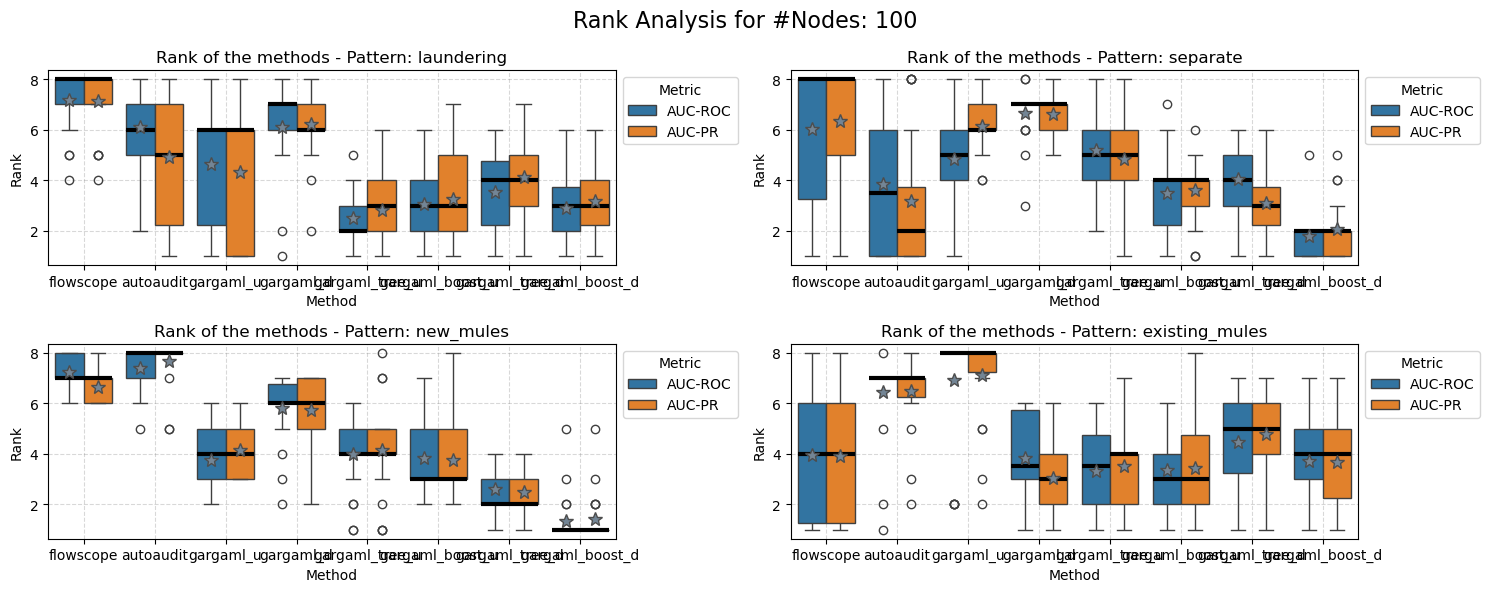

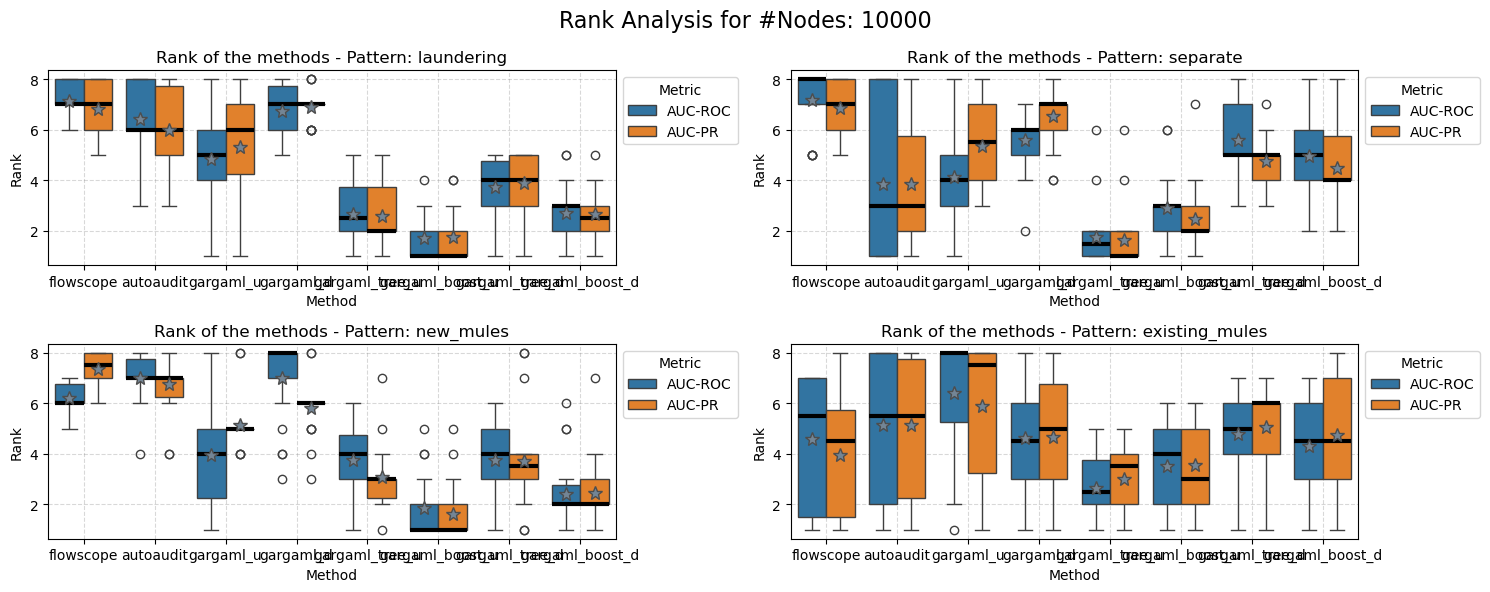

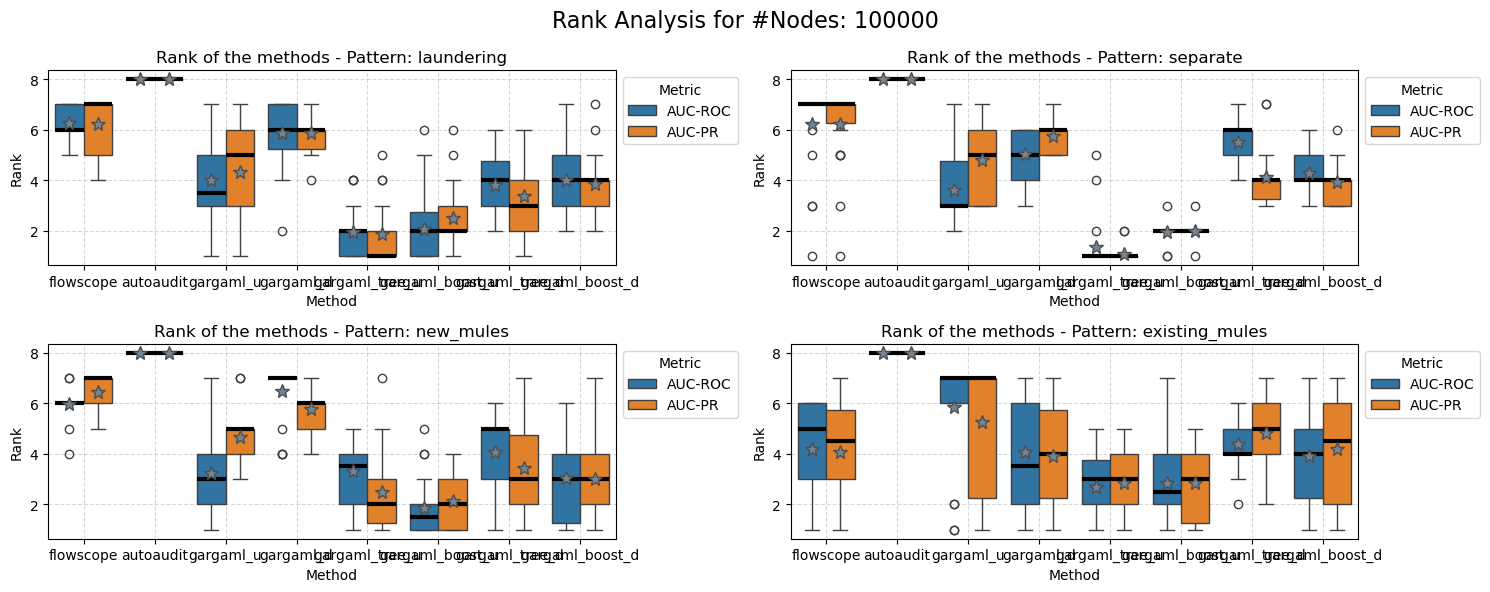

In [22]:
for n_nodes in n_nodes_list:
    datasets_nodes = [dataset for dataset in datasets if dataset.split('_')[2] == str(n_nodes)]    
    fig, axes = plt.subplots(2, 2, figsize=(15, 6))

    for idx, pattern in enumerate(patterns):
        sorted_models_ROC_list = []
        sorted_models_PR_list = []

        for dataset in datasets_nodes:
            order_ROC, order_PR = give_order(models, pattern, dataset)
            for i in order_ROC:
                sorted_models_ROC_list.append(i)
            for i in order_PR:
                sorted_models_PR_list.append(i)
        
        dict_order_ROC = {}
        dict_order_PR = {}

        for model in models:
            dict_order_ROC[model] = []
            dict_order_PR[model] = []
            for i in sorted_models_ROC_list:
                dict_order_ROC[model].append(i.index(model) + 1)
            for i in sorted_models_PR_list:
                dict_order_PR[model].append(i.index(model) + 1)

        combined_data = []
        for model in models:
            for value in dict_order_ROC[model]:
                combined_data.append({'Method': model, 'Rank': value, 'Metric': 'AUC-ROC'})
            for value in dict_order_PR[model]:
                combined_data.append({'Method': model, 'Rank': value, 'Metric': 'AUC-PR'})
        
        combined_df = pd.DataFrame(combined_data)

        # Plot the boxplot
        sns.boxplot(ax=axes[idx//2, idx%2], x='Method', y='Rank', hue='Metric', data=combined_df, palette='tab10', showmeans=True, medianprops={'color': 'black', 'linewidth':2,'label': '_median_', 'linewidth':3}, meanprops={'marker':'*', 'markerfacecolor':'xkcd:steel', 'markeredgecolor':'.3', 'markersize': 10})
        axes[idx//2, idx%2].set_title('Rank of the methods - Pattern: '+ pattern)
        axes[idx//2, idx%2].set_xlabel('Method')
        axes[idx//2, idx%2].set_ylabel('Rank')
        axes[idx//2, idx%2].legend(title='Metric', bbox_to_anchor=(1.0, 1), loc='upper left')
        axes[idx//2, idx%2].grid(True,which="both",ls="--",c='gray', alpha=0.3)  
    fig.suptitle(f'Rank Analysis for #Nodes: {n_nodes}', fontsize=16)
    plt.tight_layout()
    plt.savefig('boxplot_rank_'+str(n_nodes)+'_full.pdf')


## Statistical test of the ranks

Two statistical tests are applied. First, the Friedman test is used to test if there are statistically significant differences in the mean ranks of the methods. If there is, we apply the post-hoc Nemenyi test to compare the methods two-by-two and to construct the critical distance diagrams. 

In [23]:
import numpy as np
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import matplotlib.pyplot as plt

### Friedman Test

Friedman test statistic: 6.8333, p-value: 0.1450
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [2.5        2.16666667 4.         3.83333333 2.5       ]


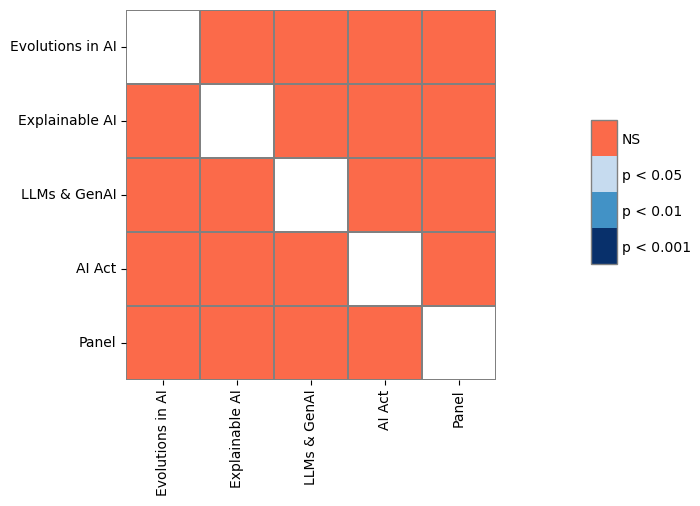

In [24]:
# Example scores of 6 classifiers over 5 datasets
# Rows = datasets, Columns = models
scores = np.array([
    [3.00, 2.00, 4.00, 5.00, 1.00],
    [2.00, 2.00, 2.00, 2.00, 2.00],
    [5.00, 3.00, 4.00, 2.00, 1.00],
    [3.00, 1.00, 5.00, 4.00, 2.00],
    [1.00, 2.00, 4.00, 3.00, 5.00],
    [2.00, 2.00, 2.00, 3.00, 1.00],
])

# Run the Friedman test
stat, p = friedmanchisquare(*scores.T)

print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")

if p < 0.2:
    print("Significant differences found — proceeding with Critical Distance Diagram")

    # Compute ranks (1 = best, higher = worse)
    ranks = np.argsort(np.argsort(scores, axis=1), axis=1) + 1  # ascending order

    # Average ranks per model
    avg_ranks = np.mean(ranks, axis=0)
    print("Average ranks:", avg_ranks)

    nf = sp.posthoc_nemenyi_friedman(scores)
    nf.index=['Evolutions in AI','Explainable AI','LLMs & GenAI', 'AI Act', 'Panel']
    nf.columns=['Evolutions in AI','Explainable AI','LLMs & GenAI', 'AI Act', 'Panel']
    # Format: diagonal, non-significant, p<0.001, p<0.01, p<0.05
    cmap = ['1', '#fb6a4a',  '#08306b',  '#4292c6', '#c6dbef']
    heatmap_args = {'cmap': cmap, 'linewidths': 0.25, 'linecolor': '0.5', 'square': True}
    sp.sign_plot(nf, **heatmap_args)

else:
    print("No statistically significant differences found — skipping post-hoc analysis.")


{'markers': [<matplotlib.collections.PathCollection at 0x33042da10>,
 'elbows': [<matplotlib.lines.Line2D at 0x3279b2dd0>,
 'labels': [Text(2.1566666666666667, -2, 'Explainable AI (2.2)'),
  Text(2.1566666666666667, -3, 'Evolutions in AI (2.5)'),
  Text(4.01, -2, '(4) LLMs & GenAI'),
  Text(4.01, -3, '(3.8) AI Act'),
  Text(4.01, -4, '(2.5) Panel')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x32791d850>]]}

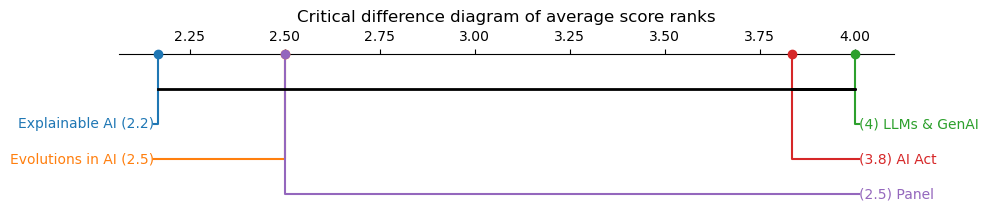

In [25]:
avg_ranks_dict = {}
for i, model in enumerate(nf.index):
    avg_ranks_dict[model] = avg_ranks[i]
avg_ranks_dict
plt.figure(figsize=(10, 2))
plt.title('Critical difference diagram of average score ranks')
sp.critical_difference_diagram(avg_ranks_dict, nf)

In [26]:
df_selection = df[(df['pattern']=='laundering')&(df['performance_metric']=='AUC-ROC')][['dataset', 'method', 'performance']]
avg_rank = df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()
avg_rank

method
autoaudit          6.833333
flowscope          6.878788
gargaml_boost_d    3.053030
gargaml_boost_u    2.166667
gargaml_d          6.280303
gargaml_tree_d     3.681818
gargaml_tree_u     2.568182
gargaml_u          4.537879
Name: performance, dtype: float64

In [27]:
df_selection

,dataset,method,performance
2,synthetic_Barabasi-Albert_100_1_0_3,flowscope,0.660428
18,synthetic_Barabasi-Albert_100_1_0_3,autoaudit,0.562643
34,synthetic_Barabasi-Albert_100_1_0_3,gargaml_u,0.561688
50,synthetic_Barabasi-Albert_100_1_0_3,gargaml_d,0.674561
66,synthetic_Barabasi-Albert_100_1_0_3,gargaml_tree_u,0.815735
...,...,...,...
8370,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_d,0.583076
8386,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_tree_u,0.838235
8402,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_boost_u,0.852791
8418,synthetic_Watts-Strogatz_100000_5_0.01_5,gargaml_tree_d,0.779412


In [28]:
dict_data = {}
for method in models:
    dict_data[method] = []
    for dataset in datasets:
        dict_data[method].append(results_dict[dataset][method]['laundering']['AUC-ROC'])

In [29]:
df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()

method
autoaudit          6.833333
flowscope          6.878788
gargaml_boost_d    3.053030
gargaml_boost_u    2.166667
gargaml_d          6.280303
gargaml_tree_d     3.681818
gargaml_tree_u     2.568182
gargaml_u          4.537879
Name: performance, dtype: float64

Friedman test statistic: 293.1605, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.86363636 6.83333333 4.5        6.22727273 2.37878788 2.28787879
 3.6969697  3.21212121]


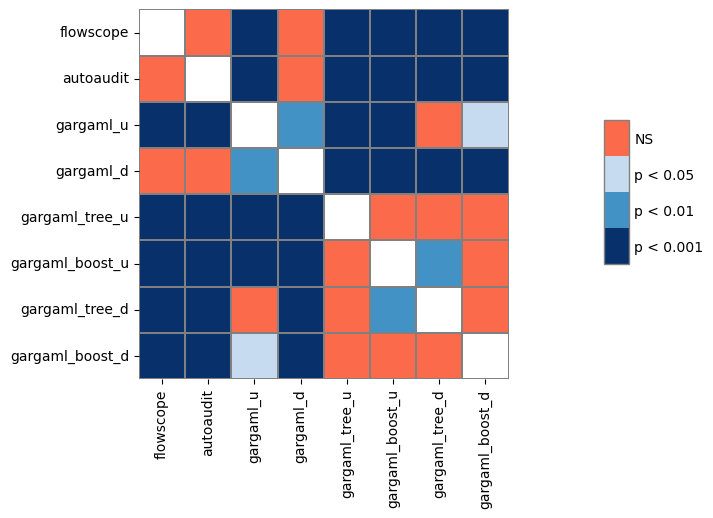

In [30]:
scores = np.array(list(dict_data.values())).T

# Run the Friedman test
stat, p = friedmanchisquare(*scores.T)

print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")

if p<0.05:
    print("Significant differences found — proceeding with Critical Distance Diagram")

    # Compute ranks (1 = best, higher = worse)
    ranks = np.argsort(np.argsort(-scores, axis=1), axis=1) + 1  # descending order

    # Average ranks per model
    avg_ranks = np.mean(ranks, axis=0)
    print("Average ranks:", avg_ranks)

    nf = sp.posthoc_nemenyi_friedman(scores)
    model_names = list(dict_data.keys())
    nf.index=nf.columns=model_names
    
    # Format: diagonal, non-significant, p<0.001, p<0.01, p<0.05
    cmap = ['1', '#fb6a4a',  '#08306b',  '#4292c6', '#c6dbef']
    heatmap_args = {'cmap': cmap, 'linewidths': 0.25, 'linecolor': '0.5', 'square': True}
    sp.sign_plot(nf, **heatmap_args)

else:
    print("No statistically significant differences found — skipping post-hoc analysis.")


{'markers': [<matplotlib.collections.PathCollection at 0x326c2f090>,
 'elbows': [<matplotlib.lines.Line2D at 0x332238c10>,
 'labels': [Text(2.1566666666666667, -3, 'GARG-AML Undir. Boost [2.17]  '),
  Text(2.1566666666666667, -4, 'GARG-AML Undir. Tree [2.57]  '),
  Text(2.1566666666666667, -5, 'GARG-AML Dir. Boost [3.05]  '),
  Text(2.1566666666666667, -6, 'GARG-AML Dir. Tree [3.68]  '),
  Text(6.888787878787879, -3, '  [6.88] FlowScope'),
  Text(6.888787878787879, -4, '  [6.83] AutoAudit'),
  Text(6.888787878787879, -5, '  [6.28] GARG-AML Directed'),
  Text(6.888787878787879, -6, '  [4.54] GARG-AML Undirected')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x332777d90>],
  [<matplotlib.lines.Line2D at 0x327b591d0>]]}

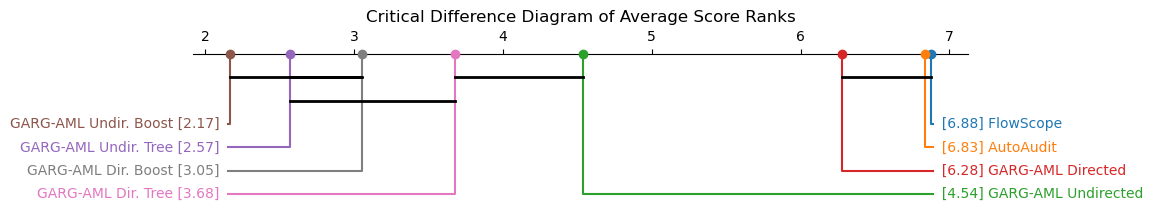

In [31]:
# Define the colors for the models based on their order in the boxplot
model_colors = {
    'flowscope': 'tab:blue',
    'autoaudit': 'tab:orange',
    'gargaml_u': 'tab:green',
    'gargaml_d': 'tab:red', 
    'gargaml_tree_u': 'tab:purple',
    'gargaml_boost_u': 'tab:brown', 
    'gargaml_tree_d': 'tab:pink',
    'gargaml_boost_d': 'tab:gray'
}

pretty_model_names = dict(MODEL_DISPLAY_NAMES)



avg_ranks_dict = dict(df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean())

# --- IMPORTANT: Create a new dictionary with PRETTY labels ---
avg_ranks_pretty = {pretty_model_names[model]: rank for model, rank in avg_ranks_dict.items()}
nf.rename(index=pretty_model_names, columns=pretty_model_names, inplace=True)

# Also adapt the color palette using pretty labels
color_palette_pretty = {pretty_model_names[model]: model_colors[model] for model in avg_ranks_dict.keys()}

# Now plot with pretty names
plt.figure(figsize=(10, 2))
plt.title('Critical Difference Diagram of Average Score Ranks')
sp.critical_difference_diagram(
    ranks=avg_ranks_pretty,
    #ranks=avg_ranks_dict,
    sig_matrix=nf,  # Assuming nf matches the order of avg_ranks_dict
    label_fmt_left='{label} [{rank:.2f}]  ',
    label_fmt_right='  [{rank:.2f}] {label}',
    color_palette=color_palette_pretty,
    #color_palette={model: model_colors[model] for model in avg_ranks_dict.keys()}
)

Friedman test statistic: 293.1605, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.86363636 6.83333333 4.5        6.22727273 2.37878788 2.28787879
 3.6969697  3.21212121]
Friedman test statistic: 155.2720, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.48484848 5.24242424 4.21212121 5.77272727 2.77272727 2.78787879
 5.04545455 3.68181818]
Friedman test statistic: 310.7713, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.46969697 7.46969697 3.65151515 6.43939394 3.6969697  2.51515152
 3.48484848 2.27272727]
Friedman test statistic: 129.5274, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [4.24242424 6.53030303 6.39393939 4.18181818 2.87878788 3.24242424
 4.54545455 3.98484848]


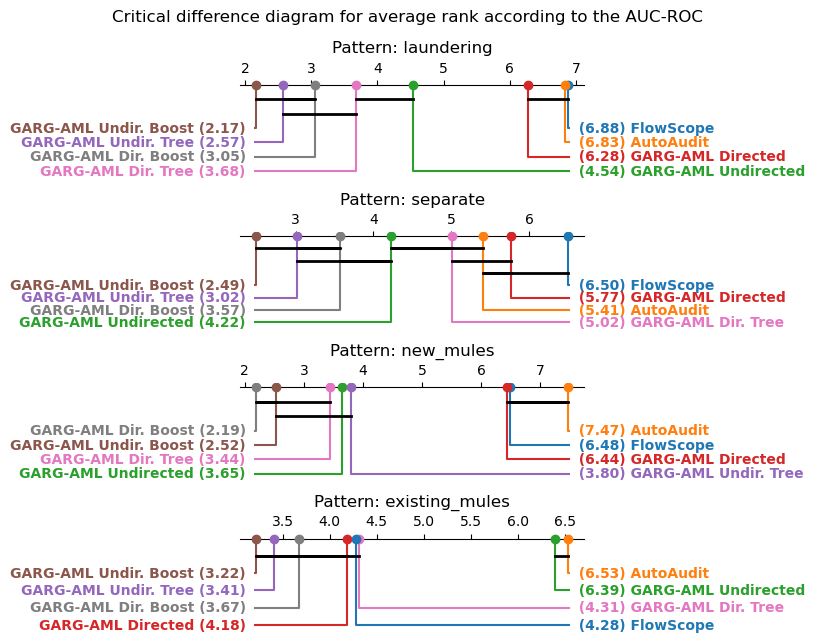

In [32]:
friedman_stats_roc = []
nemenyi_matrices_roc = {}

fig, axes = plt.subplots(4, 1, figsize=(8, 6.5))

for i_ax in range(4):
    pattern = patterns[i_ax]

    df_selection = df[(df['pattern']==pattern)&(df['performance_metric']=='AUC-ROC')][['dataset', 'method', 'performance']]
    avg_rank = df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()

    dict_data = {}
    for method in models:
        dict_data[method] = []
        for dataset in datasets:
            dict_data[method].append(results_dict[dataset][method][pattern]['AUC-ROC'])        

    scores = np.array(list(dict_data.values())).T

    # Run the Friedman test
    stat, p = friedmanchisquare(*scores.T)

    print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")
    friedman_stats_roc.append({
        'pattern': pattern,
        'chi2': float(stat),
        'p_value': float(p),
        'df': scores.shape[1] - 1,   # k - 1
        'N_datasets': scores.shape[0],
        'k_methods': scores.shape[1],
    })

    if p<0.05:
        print("Significant differences found — proceeding with Critical Distance Diagram")

        # Compute ranks (1 = best, higher = worse)
        ranks = np.argsort(np.argsort(-scores, axis=1), axis=1) + 1  # descending order

        # Average ranks per model
        avg_ranks = np.mean(ranks, axis=0)
        print("Average ranks:", avg_ranks)

        nf = sp.posthoc_nemenyi_friedman(scores)
        model_names = list(dict_data.keys())
        nf.index=nf.columns=model_names
        nemenyi_matrices_roc[pattern] = nf.copy()

        avg_ranks_dict = dict(df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean())

        # --- IMPORTANT: Create a new dictionary with PRETTY labels ---
        avg_ranks_pretty = {pretty_model_names[model]: rank for model, rank in avg_ranks_dict.items()}
        nf.rename(index=pretty_model_names, columns=pretty_model_names, inplace=True)

        # Also adapt the color palette using pretty labels
        color_palette_pretty = {pretty_model_names[model]: model_colors[model] for model in avg_ranks_dict.keys()}
        
        axes[i_ax].set_title('Pattern: '+pattern)
        sp.critical_difference_diagram(
            ranks=avg_ranks_pretty,
            # ranks=avg_ranks_dict,
            sig_matrix=nf,
            label_fmt_left='{label} ({rank:.2f})  ',
            label_fmt_right='  ({rank:.2f}) {label}',
            label_props={'fontweight': 'bold'},
            color_palette= color_palette_pretty, 
            # color_palette={model: model_colors[model] for model in avg_ranks_dict.keys()},
            ax=axes[i_ax]
            )
        
        # Get correct handles and labels
        handles, labels = axes[i_ax].get_legend_handles_labels()

    else:
        print("No statistically significant differences found — skipping post-hoc analysis.")

plt.suptitle('Critical difference diagram for average rank according to the AUC-ROC')
plt.tight_layout()
plt.savefig('../results/CD_ROC_full.pdf')

Friedman test statistic: 246.3011, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.72727273 6.3030303  4.65151515 6.33333333 2.42424242 2.51515152
 3.8030303  3.24242424]
Friedman test statistic: 191.9136, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.48484848 5.01515152 5.43939394 6.31818182 2.53030303 2.6969697
 4.         3.51515152]
Friedman test statistic: 311.2633, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [6.81818182 7.48484848 4.65151515 5.77272727 3.24242424 2.51515152
 3.22727273 2.28787879]
Friedman test statistic: 114.8847, p-value: 0.0000
Significant differences found — proceeding with Critical Distance Diagram
Average ranks: [3.98484848 6.54545455 6.10606061 3.87878788 3.12121212 3.28787879
 4.87878788 4.1969697 ]


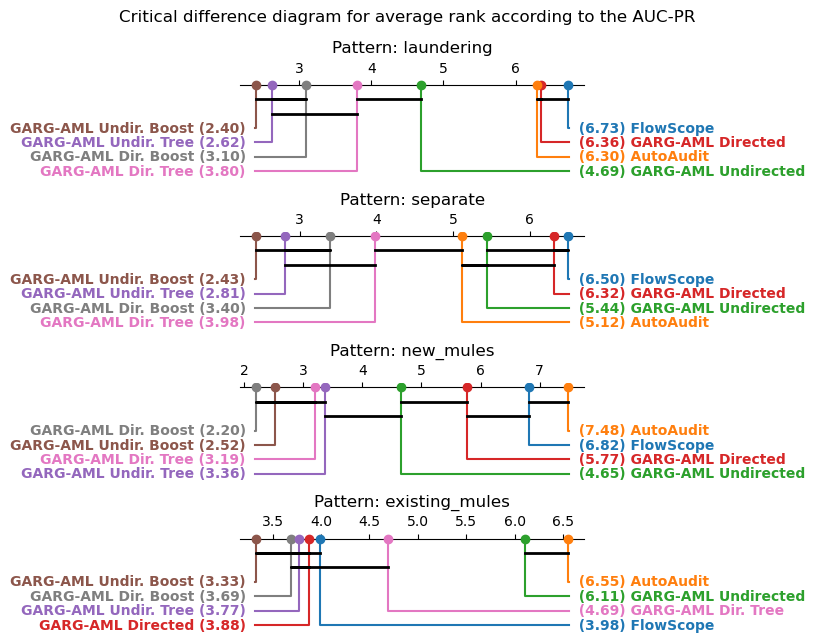

In [33]:
friedman_stats_pr = []
nemenyi_matrices_pr = {}

fig, axes = plt.subplots(4, 1, figsize=(8, 6.5))

for i_ax in range(4):
    pattern = patterns[i_ax]

    df_selection = df[(df['pattern']==pattern)&(df['performance_metric']=='AUC-PR')][['dataset', 'method', 'performance']]
    avg_rank = df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean()

    dict_data = {}
    for method in models:
        dict_data[method] = []
        for dataset in datasets:
            dict_data[method].append(results_dict[dataset][method][pattern]['AUC-PR'])        

    scores = np.array(list(dict_data.values())).T

    # Run the Friedman test
    stat, p = friedmanchisquare(*scores.T)

    print(f"Friedman test statistic: {stat:.4f}, p-value: {p:.4f}")
    friedman_stats_pr.append({
        'pattern': pattern,
        'chi2': float(stat),
        'p_value': float(p),
        'df': scores.shape[1] - 1,   # k - 1
        'N_datasets': scores.shape[0],
        'k_methods': scores.shape[1],
    })

    if p<0.05:
        print("Significant differences found — proceeding with Critical Distance Diagram")

        # Compute ranks (1 = best, higher = worse)
        ranks = np.argsort(np.argsort(-scores, axis=1), axis=1) + 1  # descending order

        # Average ranks per model
        avg_ranks = np.mean(ranks, axis=0)
        print("Average ranks:", avg_ranks)

        nf = sp.posthoc_nemenyi_friedman(scores)
        model_names = list(dict_data.keys())
        nf.index=nf.columns=model_names
        nemenyi_matrices_pr[pattern] = nf.copy()

        avg_ranks_dict = dict(df_selection.groupby('dataset').performance.rank(ascending=False).groupby(df_selection.method).mean())

        # --- IMPORTANT: Create a new dictionary with PRETTY labels ---
        avg_ranks_pretty = {pretty_model_names[model]: rank for model, rank in avg_ranks_dict.items()}
        nf.rename(index=pretty_model_names, columns=pretty_model_names, inplace=True)

        # Also adapt the color palette using pretty labels
        color_palette_pretty = {pretty_model_names[model]: model_colors[model] for model in avg_ranks_dict.keys()}

        axes[i_ax].set_title('Pattern: '+pattern)
        sp.critical_difference_diagram(
            ranks=avg_ranks_pretty,
            # ranks=avg_ranks_dict,
            sig_matrix=nf,
            label_fmt_left='{label} ({rank:.2f})  ',
            label_fmt_right='  ({rank:.2f}) {label}',
            label_props={'fontweight': 'bold'},
            color_palette= color_palette_pretty, 
            # color_palette={model: model_colors[model] for model in avg_ranks_dict.keys()},
            ax=axes[i_ax]
            )
    else:
        print("No statistically significant differences found — skipping post-hoc analysis.")

plt.suptitle('Critical difference diagram for average rank according to the AUC-PR')
plt.tight_layout()
plt.savefig('../results/CD_PR_full.pdf')

## Friedman + Nemenyi: statistics for the appendix

The cells above run the Friedman test (Friedman 1937, 1940) once per pattern
&times; metric and plot the post-hoc Nemenyi (Nemenyi 1963) Critical Difference
diagram. This section consolidates the test statistics so the values can be
quoted directly in the paper.

**Method (matches the implementation):**

1. For each of the 4 injection patterns &times; 2 threshold-free metrics
   (AUC-ROC, AUC-PR), we collect the performance of the $k = 8$ methods on the
   $N = 66$ synthetic datasets, giving an $N \times k$ score matrix.
2. We run `scipy.stats.friedmanchisquare` on the matrix. Under $H_0$ (all
   methods are equivalent), the statistic is approximately $\chi^2$ with
   $k - 1 = 7$ degrees of freedom.
3. We control family-wise Type I error across the 8 Friedman tests with
   **Bonferroni** (multiply each $p$ by 8) and **Holm**'s sequentially-rejective
   procedure. The Holm-adjusted $p$ is the more powerful of the two; reject
   $H_0$ when it is below $\alpha = 0.05$.
4. When $H_0$ is rejected, we run the post-hoc **Nemenyi test** via
   `scikit_posthocs.posthoc_nemenyi_friedman`, which returns a $k \times k$
   matrix of pairwise $p$-values.
5. The **Critical Distance** for the Nemenyi CD diagram is
   $\mathrm{CD} = q_\alpha \sqrt{\frac{k(k+1)}{6N}}$
   where $q_\alpha$ is the studentized range statistic divided by
   $\sqrt{2}$ (Demšar 2006, Table 5). For $k=8$ and $\alpha=0.05$,
   $q_{0.05} = 3.031$, giving $\mathrm{CD} \approx 1.29$ for $N=66$.

**How the CD-diagram cliques are derived.**
Two methods are connected by a horizontal bar (a *clique*) when the absolute
difference in their average ranks is below the Critical Distance, equivalently
when their Nemenyi pairwise $p$-value exceeds $\alpha$. The cliques are the
connected components of the graph $(V, E)$ with $V$ = methods and
$E = \{(i, j) : p_{ij} > \alpha\}$; `scikit_posthocs.critical_difference_diagram`
draws one horizontal segment per connected component, ordered from lowest
(best) rank on the left to highest on the right.

Note that the Nemenyi test inherently controls Type I error across all
$\binom{k}{2} = 28$ pairwise comparisons by using the studentized range
distribution, so no additional adjustment is needed beyond the CD threshold.


In [34]:
# --- Friedman/Nemenyi appendix (added by patch_friedman_reporting.py) ---
import numpy as np
import pandas as pd

# -- 1. Aggregate Friedman stats from cells 36 (AUC-ROC) and 37 (AUC-PR) --
rows = []
for stats_list, metric in [(friedman_stats_roc, "AUC-ROC"),
                           (friedman_stats_pr,  "AUC-PR")]:
    for s in stats_list:
        rows.append({**s, "metric": metric})
friedman_df = pd.DataFrame(rows)[
    ["metric", "pattern", "chi2", "df", "N_datasets", "k_methods", "p_value"]
]

# -- 2. Multiple-testing correction across the 8 (pattern x metric) tests --
m = len(friedman_df)
p_raw = friedman_df["p_value"].to_numpy()

# Bonferroni: simple multiplication, capped at 1.0
friedman_df["p_bonferroni"] = np.minimum(p_raw * m, 1.0)

# Holm: order p ascending, multiply by (m - rank), enforce monotonicity
order = np.argsort(p_raw)
p_holm = np.empty_like(p_raw)
running_max = 0.0
for rank, idx in enumerate(order):
    p_adj = (m - rank) * p_raw[idx]
    running_max = max(running_max, min(p_adj, 1.0))
    p_holm[idx] = running_max
friedman_df["p_holm"] = p_holm

friedman_df["reject_H0_holm_005"] = friedman_df["p_holm"] < 0.05

# -- 3. Nemenyi Critical Distance --
# Try scipy's studentized_range (scipy >= 1.7); fall back to Demsar 2006 Table 5
# for alpha = 0.05.
DEMSAR_Q_ALPHA_005 = {
    2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850,
    7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164,
}
k = int(friedman_df["k_methods"].iloc[0])
N = int(friedman_df["N_datasets"].iloc[0])
alpha = 0.05
try:
    from scipy.stats import studentized_range
    q_alpha = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)
    q_source = "scipy.stats.studentized_range"
except (ImportError, AttributeError):
    q_alpha = DEMSAR_Q_ALPHA_005[k]
    q_source = "Demsar 2006 Table 5 (hardcoded fallback)"
CD = q_alpha * np.sqrt(k * (k + 1) / (6.0 * N))

print(f"Nemenyi CD parameters: k={k}, N={N}, alpha={alpha}")
print(f"  q_alpha = {q_alpha:.4f}  (source: {q_source})")
print(f"  CD      = {CD:.4f}\n")

friedman_df["CD_nemenyi"] = CD

# -- 4. Save: per-test CSV + per-pattern Nemenyi matrices --
import os
os.makedirs("../results", exist_ok=True)
friedman_df.to_csv("../results/friedman_results.csv", index=False)
print("wrote ../results/friedman_results.csv")

for metric, nf_dict in [("AUC-ROC", nemenyi_matrices_roc),
                        ("AUC-PR",  nemenyi_matrices_pr)]:
    for pattern, nf_mat in nf_dict.items():
        path = f"../results/nemenyi_pvalues_{metric}_{pattern}.csv"
        # Rename via canonical display names so the appendix tables are
        # consistent with Tables 9-11 and Figures 8-9.
        nf_disp = nf_mat.rename(index=pretty, columns=pretty)
        nf_disp.to_csv(path)
print(f"wrote {len(nemenyi_matrices_roc) + len(nemenyi_matrices_pr)} Nemenyi matrices")

# -- 5. Paper-ready table (printed; copy-paste into the appendix) --
display_cols = ["metric", "pattern", "chi2", "df", "p_value",
                "p_bonferroni", "p_holm", "reject_H0_holm_005"]
print("\n=== Friedman test summary (k={}, N={}) ===".format(k, N))
print(friedman_df[display_cols].to_string(index=False,
                                          formatters={
                                              "chi2": "{:.3f}".format,
                                              "p_value": "{:.3e}".format,
                                              "p_bonferroni": "{:.3e}".format,
                                              "p_holm": "{:.3e}".format,
                                          }))

# LaTeX version
print("\n=== LaTeX table ===")
latex_df = friedman_df[display_cols].copy()
latex_df.columns = ["Metric", "Pattern", r"$\chi^2$", r"df", r"$p$",
                    r"$p_{\text{Bonf}}$", r"$p_{\text{Holm}}$",
                    r"Reject $H_0$ (Holm, $\alpha=0.05$)"]
print(latex_df.to_latex(index=False, escape=False,
                        float_format=lambda x: f"{x:.3e}" if x < 0.01 else f"{x:.3f}"))


Nemenyi CD parameters: k=8, N=66, alpha=0.05
  q_alpha = 3.0309  (source: scipy.stats.studentized_range)
  CD      = 1.2924

wrote ../results/friedman_results.csv
wrote 8 Nemenyi matrices

=== Friedman test summary (k=8, N=66) ===
 metric        pattern    chi2  df   p_value p_bonferroni    p_holm  reject_H0_holm_005
AUC-ROC     laundering 293.160   7 1.746e-59    1.397e-58 1.048e-58                True
AUC-ROC       separate 155.272   7 3.168e-30    2.534e-29 9.503e-30                True
AUC-ROC      new_mules 310.771   7 3.026e-63    2.421e-62 2.118e-62                True
AUC-ROC existing_mules 129.527   7 7.890e-25    6.312e-24 1.578e-24                True
 AUC-PR     laundering 246.301   7 1.697e-49    1.358e-48 8.486e-49                True
 AUC-PR       separate 191.914   7 5.908e-38    4.727e-37 2.363e-37                True
 AUC-PR      new_mules 311.263   7 2.375e-63    1.900e-62 1.900e-62                True
 AUC-PR existing_mules 114.885   7 8.884e-22    7.107e-21 8.884e-

/var/folders/4k/ddtlfd5s5qx15d9h74bj_v6h0000gn/T/ipykernel_21545/1988498461.py:93: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(latex_df.to_latex(index=False, escape=False,


# IBM Dataset

In this part of the notebook, we analyse the results for the IBM data set. 

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [36]:
# GARG-AML Undirected
file = '../results-0/results_performance_IBM_undirected.txt'
with open(file, 'r') as f:
    lines = f.readlines()

model_list = []
dataset_list = []
pattern_list = []
cutoff_list = []
precision_list = []
f1_score_list = []
AUCROC_list = []
AUCPR_list = []

for line in lines:
    long_split = line.strip().split('_')
    model = pretty(gargaml_key('base', directed=False))
    dataset = long_split[0]
    pattern = long_split[1]
    cutoff_results = long_split[2].split(': ', maxsplit=3)
    cutoff = cutoff_results[0].split(' ')[0]
    try:
        results = eval(cutoff_results[-1])
    except:
        results = [0, 0, 0, 0]
    precision = results[0]
    f1_score = results[1]
    AUCROC = results[2]
    AUCPR = results[3]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    precision_list.append(precision)
    f1_score_list.append(f1_score)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)


In [37]:
# GARG-AML Directed
file = '../results-0/results_performance_IBM_directed.txt'
with open(file, 'r') as f:
    lines = f.readlines()

for line in lines:
    long_split = line.strip().split('_')
    model = pretty(gargaml_key('base', directed=True))
    dataset = long_split[0]
    pattern = long_split[1]
    cutoff_results = long_split[2].split(': ', maxsplit=3)
    cutoff = cutoff_results[0].split(' ')[0]
    try:
        results  = eval(cutoff_results[-1])
    except:
        results = [0, 0, 0, 0]
    precision = results[0]
    f1_score = results[1]
    AUCROC = results[2]
    AUCPR = results[3]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    precision_list.append(precision)
    f1_score_list.append(f1_score)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)

In [38]:
# Flowscope HI-Small
file = '../results/flowscope_performance_HI-Small.txt'
with open(file, 'r') as f:
    lines = f.readlines()

for line in lines:
    long_split = line.strip().split('_')
    model = pretty('flowscope')
    dataset = 'HI-Small'
    pattern = long_split[1]
    cutoff_results = long_split[3].split(' ', maxsplit=3)
    cutoff = cutoff_results[0]
    try:
        results  = eval(cutoff_results[-1])
    except:
        results = [0, 0]
    AUCROC = results[0]
    AUCPR = results[1]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    # FlowScope reports only AUC-ROC / AUC-PR; precision and F1 are not measured.
    precision_list.append(np.nan)
    f1_score_list.append(np.nan)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)

In [39]:
# Flowscope LI-Large
file = '../results/flowscope_performance_LI-Large.txt'
with open(file, 'r') as f:
    lines = f.readlines()

for line in lines:
    long_split = line.strip().split('_')
    print(long_split)
    model = pretty('flowscope')
    dataset = 'LI-Large'
    pattern = long_split[1]
    cutoff_results = long_split[3].split(' ', maxsplit=3)
    cutoff = cutoff_results[0]
    try:
        results  = eval(cutoff_results[-1])
    except:
        results = [0, 0]
    AUCROC = results[0]
    AUCPR = results[1]
    model_list.append(model)
    dataset_list.append(dataset)
    pattern_list.append(pattern)
    cutoff_list.append(cutoff)
    # FlowScope reports only AUC-ROC / AUC-PR; precision and F1 are not measured.
    precision_list.append(np.nan)
    f1_score_list.append(np.nan)
    AUCROC_list.append(AUCROC)
    AUCPR_list.append(AUCPR)

['Pattern', 'Is Laundering', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978048234371, 0.002161712235748811])']
['Pattern', 'FAN-OUT', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.49999780945788463, 5.062329937353667e-05])']
['Pattern', 'FAN-IN', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978094600173, 4.9649774385584044e-05])']
['Pattern', 'GATHER-SCATTER', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978094035006, 7.54481865663287e-05])']
['Pattern', 'SCATTER-GATHER', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978092477979, 0.00014651551068687056])']
['Pattern', 'CYCLE', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.49999780938110633, 8.56701989398313e-05])']
['Pattern', 'RANDOM', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.49999780944722133, 5.5490924313299815e-05])']
['Pattern', 'BIPARTITE', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978094802773, 4.040128700003407e-05])']
['Pattern', 'STACK', 'Cutoff', '0.1 [AUC-ROC, AUC-PR]: ([0.4999978093597781, 9.540544881935757e-05])']
['Pattern', 'Is Laundering', 'Cutoff

In [40]:
models_IBM_tree = ['tree', 'boosting']
directed_list = ['undirected', 'directed']
IMB_data_list = ['HI-Small', 'LI-Large']
metrics_list = ['precision', 'f1', 'AUC_ROC', 'AUC_PR']
IBM_cutoffs = [0.1, 0.2, 0.3, 0.5, 0.9]
IBM_patterns = ['Is Laundering', 'FAN-OUT', 'FAN-IN', 'GATHER-SCATTER', 'SCATTER-GATHER', 'CYCLE', 'RANDOM', 'BIPARTITE', 'STACK']

for ds in IMB_data_list:
    for d in directed_list:
        for m in models_IBM_tree:
            for cut_off in IBM_cutoffs:
                for pattern in IBM_patterns:
                    variant = 'boost' if m == 'boosting' else m
                    model_list.append(pretty(gargaml_key(variant, directed=(d == 'directed'))))
                    dataset_list.append(ds)
                    pattern_list.append(pattern)
                    cutoff_list.append(str(cut_off))
                    for pm in metrics_list:
                        file = '../results/'+ds+'_'+pm+'_'+m+'_'+d+'_combined.csv'
                        df = pd.read_csv(file, index_col=0)
                        if pm == 'precision':
                            precision = df.loc[cut_off][pattern]
                            precision_list.append(precision)
                        elif pm == 'f1':
                            f1_score = df.loc[cut_off][pattern]
                            f1_score_list.append(f1_score)
                        elif pm == 'AUC_ROC':
                            AUC = df.loc[cut_off][pattern]
                            AUCROC_list.append(AUC)
                        else:
                            AUC = df.loc[cut_off][pattern]
                            AUCPR_list.append(AUC)



In [41]:
results_df = pd.DataFrame({
    'model': model_list,
    'dataset': dataset_list,
    'pattern': pattern_list,
    'cutoff': cutoff_list,
    'Precision': precision_list,
    'F1-score': f1_score_list,
    'AUC-ROC': AUCROC_list,
    'AUC-PR': AUCPR_list
})

ValueError: All arrays must be of the same length

In [ ]:
results_df.fillna(0, inplace=True)

In [ ]:
results_df.head()

In [ ]:
results_plot_df = results_df[(results_df['dataset']==dataset) & (results_df['pattern'].isin(['Is Laundering', 'GATHER-SCATTER', 'SCATTER-GATHER'])) & (results_df['cutoff'].isin(['0.1', '0.5' ,'0.9']))]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = ['HI-Small', 'LI-Large']
for dataset in datasets:
    results_plot_df = results_df[(results_df['dataset']==dataset) & (results_df['pattern'].isin(['Is Laundering', 'GATHER-SCATTER', 'SCATTER-GATHER'])) & (results_df['cutoff'].isin(['0.1', '0.5' ,'0.9']))]

    # Ensure consistent aesthetics
    sns.set(style="whitegrid")

    # Assume results_plot_df is already defined
    # Extract unique patterns and cutoffs
    patterns = results_plot_df['pattern'].unique()
    cutoffs = results_plot_df['cutoff'].unique()
    models = [pretty(k) for k in [
        'flowscope',
        'gargaml_u', 'gargaml_d',
        'gargaml_tree_u', 'gargaml_boost_u',
        'gargaml_tree_d', 'gargaml_boost_d',
    ]]
    palette = sns.color_palette("tab10", len(models)+1)
    del (palette[1])

    # Create a mapping from model names to colors
    model_color_map = dict(zip(models, palette))

    # Create the subplot grid
    fig, axes = plt.subplots(len(patterns), len(cutoffs), figsize=(6.5 * len(cutoffs), 3 * len(patterns)), squeeze=False)

    for i, pattern in enumerate(patterns):
        for j, cutoff in enumerate(cutoffs):
            ax = axes[i, j]
            subset = results_plot_df[(results_plot_df['pattern'] == pattern) & (results_plot_df['cutoff'] == cutoff)]
            ylim_max = subset['AUC-ROC'].max()*1.1
            ax.set_ylim(0, ylim_max)
            # Primary bar plot for AUC-ROC
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                roc = model_data['AUC-ROC'].values[0]
                ax.bar(idx - 0.2, model_data['AUC-ROC'], width=0.4, label=model if i == 0 and j == 0 else "", 
                    color=model_color_map[model], edgecolor='black')
                ax.text(idx - 0.23, roc-0.001, f"{roc*100:.1f}%", ha='center', va='bottom', fontsize=8)
            
            # Twin axis for AUC-PR
            ylim_max_2 = subset['AUC-PR'].max()*1.1
            ax2 = ax.twinx()
            ax2.set_ylim(0, ylim_max_2)
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                pr = model_data['AUC-PR'].values[0]
                ax2.bar(idx + 0.2, model_data['AUC-PR'], width=0.4, label=None, 
                        color=model_color_map[model], hatch='//', alpha=0.7, edgecolor='black')
                ax2.text(idx + 0.28, pr, f"{pr*100:.3f}%", ha='center', va='bottom', fontsize=8)

            ax.set_title(f"Pattern: {pattern} | Cutoff: {cutoff}")
            ax.set_xticks([])
            ax.set_xticklabels([])
            ax.set_ylabel("AUC-ROC")
            ax2.set_ylabel("AUC-PR")

    # Add legend only once
    handles = [plt.Rectangle((0,0),1,1, color=model_color_map[m]) for m in models]
    fig.legend(handles, models, loc='upper center', ncol=len(models), title='Models - '+dataset, fontsize=12, title_fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig('../results/'+dataset+'_AUC-ROC_AUC-PR.pdf')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = ['HI-Small', 'LI-Large']
for dataset in datasets:
    results_plot_df = results_df[(results_df['dataset']==dataset)]

    # Ensure consistent aesthetics
    sns.set(style="whitegrid")

    # Assume results_plot_df is already defined
    # Extract unique patterns and cutoffs
    patterns = results_plot_df['pattern'].unique()
    cutoffs = results_plot_df['cutoff'].unique()
    models = [pretty(k) for k in [
        'flowscope',
        'gargaml_u', 'gargaml_d',
        'gargaml_tree_u', 'gargaml_boost_u',
        'gargaml_tree_d', 'gargaml_boost_d',
    ]]
    palette = sns.color_palette("tab10", len(models)+1)
    del (palette[1])

    # Create a mapping from model names to colors
    model_color_map = dict(zip(models, palette))

    # Create the subplot grid
    fig, axes = plt.subplots(len(patterns), len(cutoffs), figsize=(7 * len(cutoffs), 3 * len(patterns)), squeeze=False)

    for i, pattern in enumerate(patterns):
        for j, cutoff in enumerate(cutoffs):
            ax = axes[i, j]
            subset = results_plot_df[(results_plot_df['pattern'] == pattern) & (results_plot_df['cutoff'] == cutoff)]
            ylim_max = subset['AUC-ROC'].max()*1.1
            ax.set_ylim(0, ylim_max)
            # Primary bar plot for AUC-ROC
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                roc = model_data['AUC-ROC'].values[0]
                ax.bar(idx - 0.2, model_data['AUC-ROC'], width=0.4, label=model if i == 0 and j == 0 else "", 
                    color=model_color_map[model], edgecolor='black')
                ax.text(idx - 0.23, roc-0.001, f"{roc*100:.1f}%", ha='center', va='bottom', fontsize=8)
            
            # Twin axis for AUC-PR
            ylim_max_2 = subset['AUC-PR'].max()*1.1
            ax2 = ax.twinx()
            ax2.set_ylim(0, ylim_max_2)
            for idx, model in enumerate(models):
                model_data = subset[subset['model'] == model]
                pr = model_data['AUC-PR'].values[0]
                ax2.bar(idx + 0.2, model_data['AUC-PR'], width=0.4, label=None, 
                        color=model_color_map[model], hatch='//', alpha=0.7, edgecolor='black')
                ax2.text(idx + 0.28, pr, f"{pr*100:.3f}%", ha='center', va='bottom', fontsize=8)

            ax.set_title(f"Pattern: {pattern} | Cutoff: {cutoff}", fontsize=20)
            ax.set_xticks([])
            ax.set_xticklabels([])
            #ax.set_xticks(range(len(models)))
            #ax.set_xticklabels(models, rotation=45, ha='right')
            ax.set_ylabel("AUC-ROC")
            ax2.set_ylabel("AUC-PR")

    # Add legend only once
    handles = [plt.Rectangle((0,0),1,1, color=model_color_map[m]) for m in models]
    fig.legend(handles, models, loc='upper center', ncol=len(models), title='Models - '+dataset, fontsize=21, title_fontsize=28)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig('../results/'+dataset+'_AUC-ROC_AUC-PR_full.pdf')

In [ ]:
import pandas as pd
import numpy as np

def generate_latex_table(results_df, dataset='HI-Small'):
    # Define the ordering and exact naming conventions
    patterns_raw = ['Is Laundering', 'GATHER-SCATTER', 'SCATTER-GATHER']
    patterns_clean = ['Is Laundering', 'Gather-Scatter', 'Scatter-Gather']
    cutoffs = ['0.1', '0.5', '0.9']
    
    models = [pretty(k) for k in [
        'gargaml_u', 'gargaml_d',
        'gargaml_tree_u', 'gargaml_boost_u',
        'gargaml_tree_d', 'gargaml_boost_d',
    ]]
    

    # Filter the dataframe for the current table
    df = results_df[
        (results_df['dataset'] == dataset) & 
        (results_df['pattern'].isin(patterns_raw)) & 
        (results_df['cutoff'].isin(cutoffs))
    ].copy()

    # Scale metrics by 100 as done in the plot
    df['AUC-ROC'] = df['AUC-ROC'] * 100
    df['AUC-PR'] = df['AUC-PR'] * 100

    # Pre-calculate maximums for bolding
    max_vals = {}
    for p in patterns_raw:
        max_vals[p] = {}
        for c in cutoffs:
            subset = df[(df['pattern'] == p) & (df['cutoff'] == c)]
            max_vals[p][c] = {
                'Precision': subset['Precision'].max() if not subset.empty else -1,
                'F1-score': subset['F1-score'].max() if not subset.empty else -1,
                'AUC-ROC': subset['AUC-ROC'].max() if not subset.empty else -1,
                'AUC-PR': subset['AUC-PR'].max() if not subset.empty else -1
            }

    # Start building the LaTeX string
    latex = []
    latex.append(r"\begin{table*}[t]")
    latex.append(r"\centering")
    latex.append(r"\color{red}")
    latex.append(rf"\caption{{Performance comparison (AUC-ROC and AUC-PR) across graph patterns and cutoffs for the {dataset} dataset.}}")
    latex.append(rf"\label{{tab:results {dataset.lower().replace('-', ' ')}}}")
    latex.append(r"\tiny % Slightly smaller font to ensure fit")
    latex.append(r"\begin{tabular}{ll cccccccccccc}")
    latex.append(r"\toprule")
    latex.append(r"\multirow{2}{*}{\textbf{Pattern}} & \multirow{2}{*}{\textbf{Model}} & \multicolumn{4}{c}{\textbf{Cutoff 0.1}} & \multicolumn{4}{c}{\textbf{Cutoff 0.5}} & \multicolumn{4}{c}{\textbf{Cutoff 0.9}} \\")
    latex.append(r"\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-14}")
    latex.append(r"& & Precision & F1 & AUC-ROC & AUC-PR & Precision & F1 & AUC-ROC & AUC-PR & Precision & F1 & AUC-ROC & AUC-PR \\")
    latex.append(r"\midrule")

    # Iterate through patterns to build rows
    for i, pattern_raw in enumerate(patterns_raw):
        pattern_display = patterns_clean[i]
        latex.append(rf"\multirow{{7}}{{*}}{{\rotatebox[origin=c]{{90}}{{{pattern_display}}}}}")
        
        for j, model in enumerate(models):
            row_str = f"& {model:<21}"
            
            for cutoff in cutoffs:
                row_data = df[(df['pattern'] == pattern_raw) & (df['cutoff'] == cutoff) & (df['model'] == model)]
                
                if row_data.empty or pd.isna(row_data['AUC-ROC'].values[0]):
                    row_str += " & - & - & - & - "
                else:
                    precision = row_data['Precision'].values[0] 
                    f1_score = row_data['F1-score'].values[0] 
                    roc = row_data['AUC-ROC'].values[0]
                    pr = row_data['AUC-PR'].values[0]
                    
                    # Bold logic: compare to max_val with a small tolerance for floating point issues
                    is_max_prec = abs(precision - max_vals[pattern_raw][cutoff]['Precision']) < 1e-5  
                    is_max_f1 = abs(f1_score - max_vals[pattern_raw][cutoff]['F1-score']) < 1e-5  
                    is_max_roc = abs(roc - max_vals[pattern_raw][cutoff]['AUC-ROC']) < 1e-5
                    is_max_pr = abs(pr - max_vals[pattern_raw][cutoff]['AUC-PR']) < 1e-5
                    
                    prec_str = rf"\textbf{{{precision:.3f}}}" if is_max_prec else f"{precision:.3f}"
                    f1_str = rf"\textbf{{{f1_score:.3f}}}" if is_max_f1 else f"{f1_score:.3f}"
                    roc_str = rf"\textbf{{{roc:.1f}}}" if is_max_roc else f"{roc:.1f}"
                    pr_str = rf"\textbf{{{pr:.3f}}}" if is_max_pr else f"{pr:.3f}"
                    
                    row_str += f" & {prec_str} & {f1_str} & {roc_str} & {pr_str}"
            
            row_str += r" \\"
            latex.append(row_str)
        
        # Add a midrule after each pattern block except the last one
        if i < len(patterns_raw) - 1:
            latex.append(r"\midrule")

    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)

# --- Example Usage ---
# latex_output = generate_latex_table(results_df, dataset='HI-Small')
# print(latex_output)
# 
# # You can easily run it for the other dataset too:
# # with open('../results/LI-Large_table.tex', 'w') as f:
# #     f.write(generate_latex_table(results_df, dataset='LI-Large'))

In [ ]:
print(generate_latex_table(results_df, dataset='LI-Large'))

In [ ]:
results_df